### Intro/purpose

The purpose of this notebook will be to break down the surface terms using the diagnostics we have for the lab sea

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import xarray as xr
import h5py
from scipy.io import loadmat
import matplotlib as mpl
import time
import gsw
from matplotlib.colors import TwoSlopeNorm

# import existing python files
plt.rcParams['figure.figsize'] = (10,4)

# add rdmds reading functions to path
sys.path.append("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils/") # go to parent dir
from mds import *

# add the other files
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
from read_binary import *
from calc_UV_conv_1face import calc_UV_conv_1face
from calc_mskmean_T_mod import calc_mskmean_T_mod
from mk3D_mod import mk3D_mod
from aste_helper_funcs import *
from timing_functions import *           # ts2dte, get_fnames, etc.
from binning import *                    # bin_array, create_mesh

In [2]:
def get_vlev(values):
    return np.abs(np.nanmax(values))

### define the path to read the files

In [3]:
dirroot = "/scratch/mmurakami/labsea/layers/"
dirGrid = "/scratch2/atnguyen/labsea/GRID_r8/"
runstr= "run_c68v_layers_lessmem1_5ts_06May2026_debug2/"
layers_path = dirroot + runstr
dirbudg = layers_path + "diags/BUDG/"
dirIn = dirbudg
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirtrsp = layers_path + "diags/TRSP/"
direxf = layers_path + "diags/EXF/"
dirfluxes = layers_path + "diags/FLUXES/"

In [4]:
bigaste = False
labsea = True
oneface = False    # setting must be true for labsea

if bigaste:
    nx = 270
    ncut1 = 450
    ncut2 = 180
    ny = 2*ncut1 + nx + ncut2
    nz = 50

elif labsea:
    nx = 20
    ny = 16
    nz = 23
    ncut1 = 0
    ncut2 = 0
    
    nFaces = 1
    facesSize = np.array([[nx, ny]])
    facesExpand = np.array([[nx, ny]])
    oneface = True

else:
    nx = 90
    ncut1 = 150
    ncut2 = 60
    ny = 2*ncut1 + nx + ncut2
    nz = 50

if labsea:
    nfx = np.array([20])
    nfy = np.array([16])

else:
    nfx = np.array([nx, 0, nx, ncut2, ncut1])
    nfy = np.array([ncut1, 0, nx, nx, nx])

In [5]:
# get time-steps:
flist = [f for f in os.listdir(dirIn) if f.startswith('budg2d_snap_set1.') and f.endswith('.data')]
idot = flist[0].index('.')
idot = [idot+1, flist[0][idot+1:].index('.')+idot+1]
idot = np.asarray(idot,dtype=int)

mygrid = {
    'dirGrid': dirGrid,
    'nFaces': 1,
    'fileFormat': 'compact',
    'memoryLimit': 2,
    'ioSize': [nx*ny, 1],
    'facesSize': [ny, nx],
    'facesExpand': [ny, nx],
    'missVal': 0,
}

fldstr2d = ['XC','YC','XG','YG','RAC','Depth','DXG','DYG','DXC','DYC']
fldstr3d = ['hFacC','hFacW','hFacS','mskC','mskS','mskW']
fldstr3dp = ['hFacC','hFacW','hFacS','maskCtrlC','maskCtrlS','maskCtrlW']
fldstr1d = ['RC','RF','DRC','DRF']

for fld in fldstr1d:
    mygrid[fld] = np.squeeze(rdmds(os.path.join(dirGrid, fld)))

for fld in fldstr3d:
    temp = rdmds(os.path.join(dirGrid, fldstr3dp[fldstr3d.index(fld)]))
    mygrid[fld] = temp.reshape(nz, ny, nx)

for fld in fldstr2d:
    temp = rdmds(os.path.join(dirGrid, fld))
    mygrid[fld] = temp.reshape(ny, nx)

mygrid['mskC'][mygrid['mskC'] == 0] = np.nan

areaW, areaS, Vol = [], [], []
for k in range(nz):
    areaW.append(mygrid['DYG'] * mygrid['DRF'][k])
    areaS.append(mygrid['DXG'] * mygrid['DRF'][k])
    Vol.append(mygrid['RAC'] * mygrid['DRF'][k])

In [6]:
# block out obcs
# np tile I think operates the same as repmat in MATLAB
RAC = mygrid['RAC']
RAC3 = np.tile(RAC,(nz,1,1))

hfC = mygrid['hFacC']
DD = mygrid['Depth']
dxg = mygrid['DXG']
dyg = mygrid['DYG']
dxg3d = np.tile(dxg,(nz,1,1))
dyg3d = np.tile(dyg,(nz,1,1))

print(mygrid['DRF'].shape,np.zeros((nz, ny, nx)).shape)
drf3d = mk3D_mod(mygrid['DRF'], np.zeros((nz, ny, nx)))
DD3d = mk3D_mod(DD,np.zeros((nz, ny, nx)))

hfC[hfC == 0] = np.nan
hfC1 = hfC[0, :, :]
hfC1[hfC1 == 0] = np.nan

RACg = RAC * hfC1
hfC1p = np.copy(hfC1)

hfC1p[:, nx-1] = np.nan
hfC1p[ny-1,:] = np.nan
RACgp = RAC * hfC1p

(23,) (23, 16, 20)


In [7]:
#mygrid['hFacC'][mygrid['hFacC'] > 0] = 1
mygrid['hFacC'][mygrid['hFacC'] == 0] = np.nan
hf1 = mygrid['hFacC'][0] # top layer in z

print("hf1",hf1.shape)

if not oneface:

    hf1 = get_aste_tracer(hf1, nfx, nfy)
    # check with hardcoding on this for mini or big aste
    if nx == 90:
        hf1[:,281,:] = np.nan
        hf1[:,7,:] = np.nan
        hf1[:,86,122] = np.nan
    elif nx == 270:
        hf1[:,844,:] = np.nan
        hf1[:,23,:] = np.nan
        hf1[:,365,260:261] = np.nan

    hf1 = aste_tracer2compact(hf1,nfx,nfy)
    hf = mygrid["hFacC"]
    hf = hf * np.tile(hf1,(nz, 1,1))

hf1 (16, 20)


### we have already checked that this is closed in the other notebooks

We can load the terms, making sure to double-check the units, and add them here

In [8]:
tsstr = np.array(["0000000003","0000000004"])
t1 = int(tsstr[0])
t2 = int(tsstr[1]) # for the offline version
dt = 3600

In [9]:
def read_all_2d_diags(dirname, file_name, t2, tsstr, ny, nx):
    meta = parsemeta(os.path.join(dirname, file_name + "." + tsstr[0] + ".meta"))
    fldlist = np.array([f.strip() for f in meta["fldList"]])

    out = {}

    for irec, var in enumerate(fldlist):
        arr, its, meta_rd = rdmds(
            os.path.join(dirname, file_name),
            t2,
            returnmeta=True,
            rec=irec
        )

        if arr.size == ny * nx:
            out[var] = arr.reshape(ny, nx)
        else:
            print(f"Skipping {var}: not 2D, shape={arr.shape}")

    return out

In [10]:
# ============================================================
# load all 2D diagnostics only
# ============================================================

budg1 = read_all_2d_diags(dirIn, "budg2d_zflux_set1", t2, tsstr, ny, nx)
budg2 = read_all_2d_diags(dirIn, "budg2d_zflux_set2", t2, tsstr, ny, nx)

extra_seaice = read_all_2d_diags(
    dirfluxes, "flux_breakdown_extra_seaice", t2, tsstr, ny, nx
)

extra_exf1 = read_all_2d_diags(dirfluxes, "flux_breakdown_extra_exf", t2, tsstr, ny, nx)
extra_exf2 = read_all_2d_diags(dirfluxes, "seaice_thermo_breakdown", t2, tsstr, ny, nx)
extra_exf = {**extra_exf1, **extra_exf2}

state2d = read_all_2d_diags(dirstate, "state_2d_set1", t2, tsstr, ny, nx)

In [11]:
# ============================================================
# assign commonly used variables
# ============================================================

# fluxes
oceFWflx = budg1.get("oceFWflx")
SIatmFW  = budg1.get("SIatmFW")
TFLUX    = budg1.get("TFLUX")
SItflux  = budg1.get("SItflux")
SFLUX    = budg1.get("SFLUX")
oceQsw   = budg1.get("oceQsw")
oceSPflx = budg1.get("oceSPflx")

# flux set 2
SRELAX   = budg2.get("SRELAX")
TRELAX   = budg2.get("TRELAX")
WTHMASS  = budg2.get("WTHMASS")
WSLTMASS = budg2.get("WSLTMASS")
oceSflux = budg2.get("oceSflux")
oceQnet  = budg2.get("oceQnet")
SIatmQnt = budg2.get("SIatmQnt")
SIaaflux = budg2.get("SIaaflux")
SIsnPrcp = budg2.get("SIsnPrcp")
SIacSubl = budg2.get("SIacSubl")

# added breakdown terms
surForcT = extra_seaice.get("surForcT")
surForcS = extra_seaice.get("surForcS")
SIempmr  = extra_seaice.get("SIempmr")
SIfwSubl = extra_seaice.get("SIfwSubl")
SIrsSubl = extra_seaice.get("SIrsSubl")
SIhl     = extra_seaice.get("SIhl")
SIqneto  = extra_seaice.get("SIqneto")
SIqneti  = extra_seaice.get("SIqneti")
oceFreez = extra_seaice.get("oceFreez")  # W/m^2
EXFsnow  = extra_exf.get("EXFsnow")
EXFsnow  = extra_exf.get("EXFsnow")
# added sea-ice thermo breakdown terms
SIfwSubl = extra_exf.get("SIfwSubl")
SIacSubl = extra_exf.get("SIacSubl")
SIrsSubl = extra_exf.get("SIrsSubl")

SIaQbOCN = extra_exf.get("SIaQbOCN")
SIaQbATC = extra_exf.get("SIaQbATC")
SIaQbATO = extra_exf.get("SIaQbATO")

SIdHbOCN = extra_exf.get("SIdHbOCN")
SIdHbATC = extra_exf.get("SIdHbATC")
SIdHbATO = extra_exf.get("SIdHbATO")
SIdHbFLO = extra_exf.get("SIdHbFLO")

SIdSbATC = extra_exf.get("SIdSbATC")
SIdSbOCN = extra_exf.get("SIdSbOCN")
SIdAbATO = extra_exf.get("SIdAbATO")


# state, including sea ice
# THETA = state3d.get("THETA")
# SALT  = state3d.get("SALT")

SIarea = state2d.get("SIarea")
SIheff = state2d.get("SIheff")
SIhsnow = state2d.get("SIhsnow")
ETAN = state2d.get("ETAN")

oceFWflx_state = state2d.get("oceFWflx")

In [12]:
# also load SIheff from the snaps

file_name = 'budg2d_snap_set1'
meta_budg2d_snap_set1 = parsemeta(dirIn + file_name + "." + tsstr[0] + ".meta")

# try to read this with rec
fldlist = np.array(meta_budg2d_snap_set1['fldList'])
varnames = np.array(['ETAN','PHIBOT','SIheff','SIhsnow'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

ETAN = np.full((len(tsstr),ny,nx),np.nan)
PHIBOT = np.full((len(tsstr),ny,nx),np.nan)
SIheff = np.full((len(tsstr),ny,nx),np.nan)
SIhsnow = np.full((len(tsstr),ny,nx),np.nan)

for i in range(len(tsstr)):
    thisETAN,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[0])
    thisETAN = thisETAN.reshape(ny,nx)
    ETAN[i] = thisETAN

    thisPHIBOT,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[1])
    thisPHIBOT = thisPHIBOT.reshape(ny,nx)
    PHIBOT[i] = thisPHIBOT

    thisSIheff,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[2])
    thisSIheff = thisSIheff.reshape(ny,nx)
    SIheff[i] = thisSIheff

    thisSIhsnow,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[3])
    thisSIhsnow = thisSIhsnow.reshape(ny,nx)
    SIhsnow[i] = thisSIhsnow

ETAN =  (ETAN[1, :, :] - ETAN[0, :, :]) / dt
PHIBOT = (PHIBOT[1, :, :] - PHIBOT[0, :, :]) / dt
dSIheff =  (SIheff[1, :, :] - SIheff[0, :, :]) / dt
dSIhsnow = (SIhsnow[1, :, :] - SIhsnow[0, :, :]) / dt

### make some plots

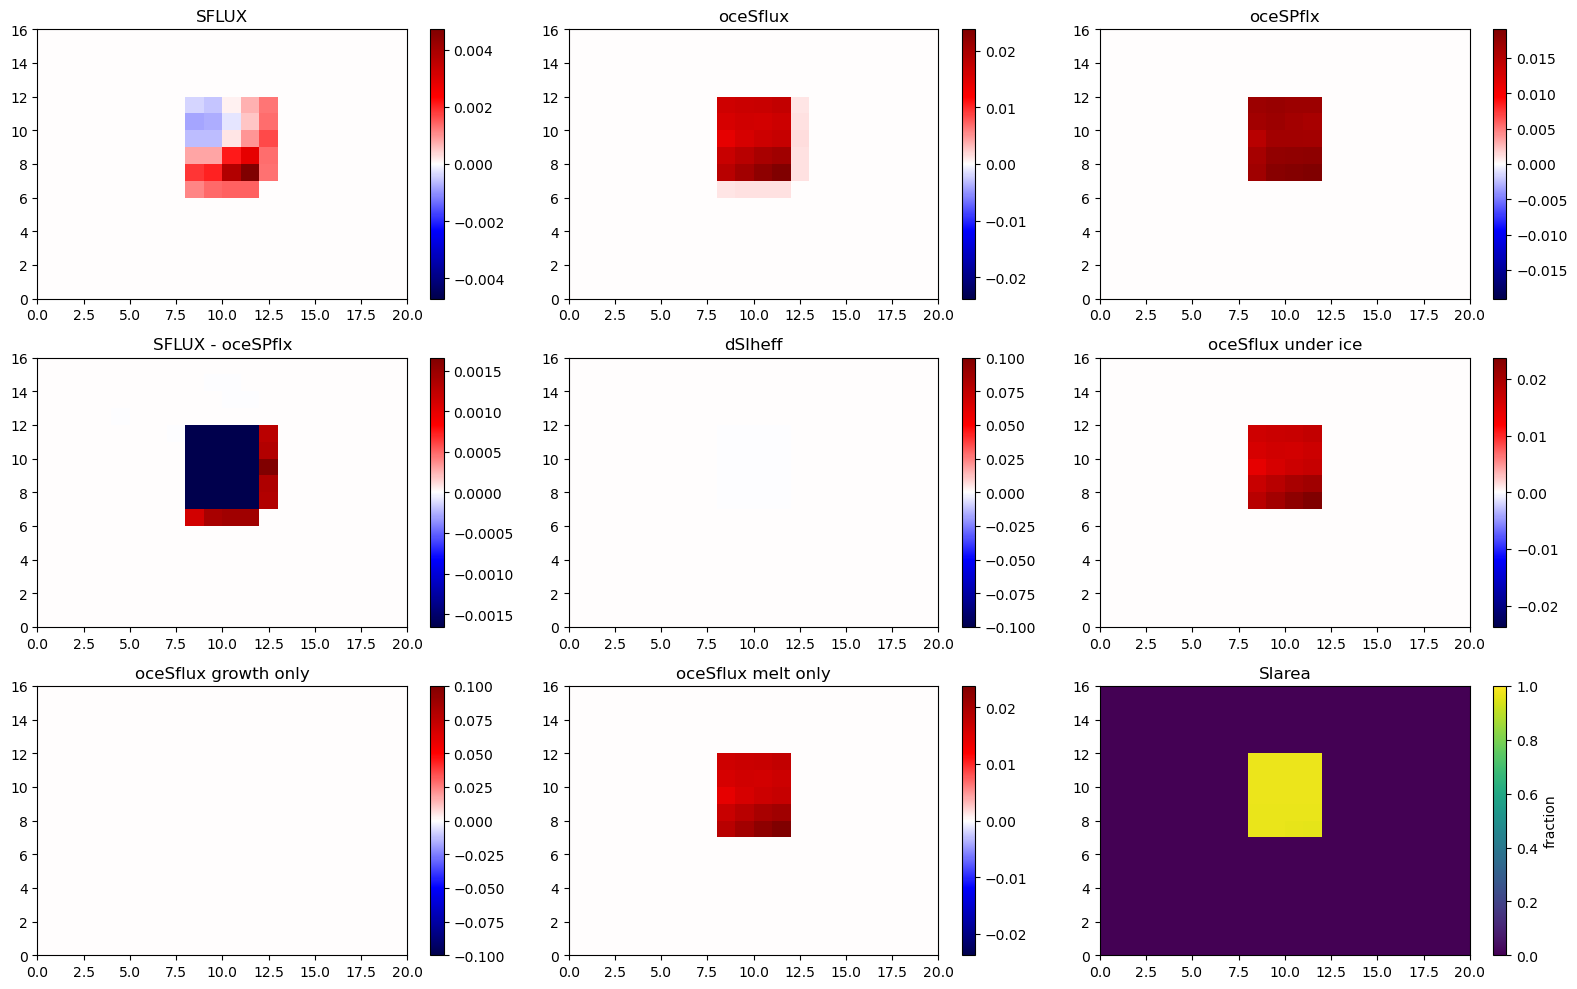

In [13]:
ice = SIarea > 0.0
growth = dSIheff > 0
melt = dSIheff < 0

fig = plt.figure(figsize=(16, 10))

terms = {
    "SFLUX": SFLUX,
    "oceSflux": oceSflux,
    "oceSPflx": oceSPflx,
    "SFLUX - oceSPflx": SFLUX - oceSPflx,
    "dSIheff": dSIheff,
    "oceSflux under ice": np.where(ice, oceSflux, 0),
    "oceSflux growth only": np.where(growth, oceSflux, 0),
    "oceSflux melt only": np.where(melt, oceSflux, 0),
    "SIarea": SIarea,
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(3, 3, n)

    if name == "SIarea":
        plt.pcolormesh(fld, cmap="viridis", vmin=0, vmax=1)
        plt.colorbar(label="fraction")
    else:
        vlev = get_vlev(fld)
        plt.pcolormesh(fld, cmap="seismic", vmin=-vlev, vmax=vlev)
        plt.colorbar()

    plt.title(name)

plt.tight_layout()
plt.show()

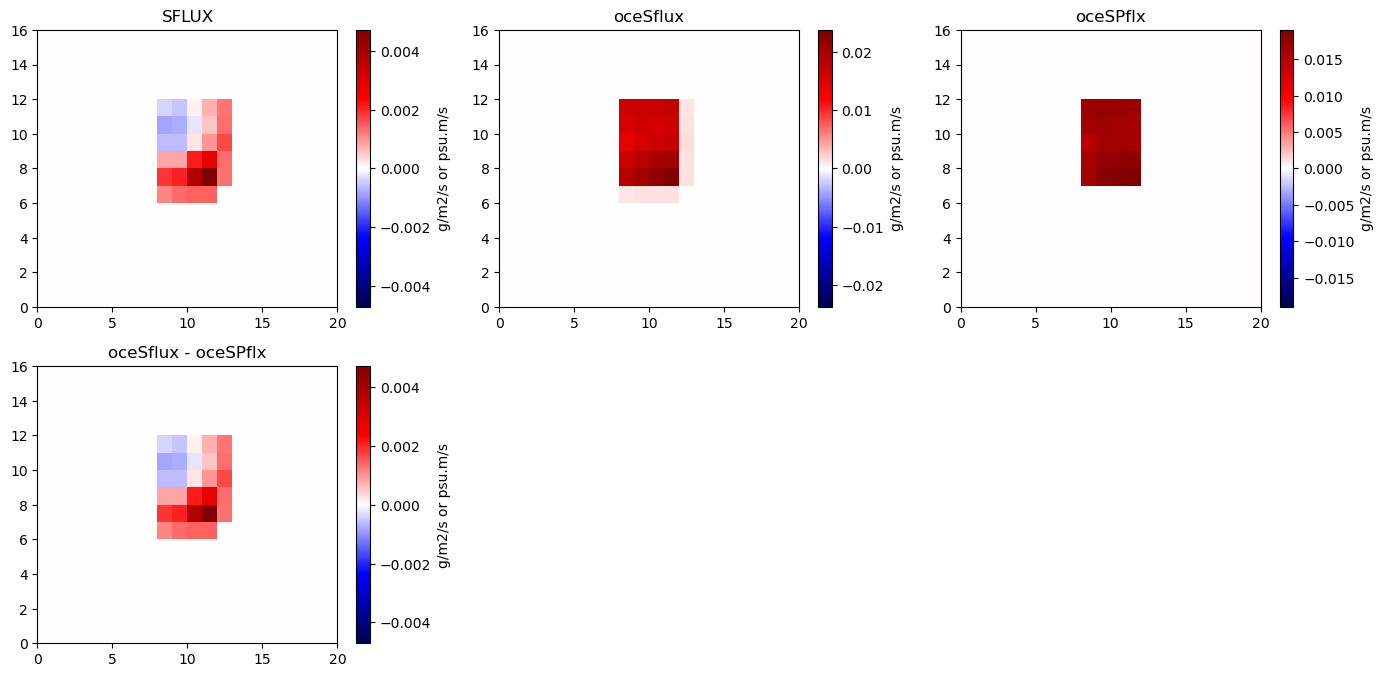

In [14]:
fig = plt.figure(figsize=(14, 10))

ax = plt.subplot(331)
vlev = get_vlev(SFLUX)
plt.pcolormesh(SFLUX, cmap='seismic', vmin=-vlev, vmax=vlev)
plt.colorbar(label="g/m2/s or psu.m/s")
plt.title("SFLUX")

ax = plt.subplot(332)
vlev = get_vlev(oceSflux)
plt.pcolormesh(oceSflux, cmap='seismic', vmin=-vlev, vmax=vlev)
plt.colorbar(label="g/m2/s or psu.m/s")
plt.title("oceSflux")

ax = plt.subplot(333)
vlev = get_vlev(oceSPflx)
plt.pcolormesh(oceSPflx, cmap='seismic', vmin=-vlev, vmax=vlev)
plt.colorbar(label="g/m2/s or psu.m/s")
plt.title("oceSPflx")

ax = plt.subplot(334)
vlev = get_vlev(oceSflux - oceSPflx)
plt.pcolormesh(oceSflux - oceSPflx, cmap='seismic', vmin=-vlev, vmax=vlev)
plt.colorbar(label="g/m2/s or psu.m/s")
plt.title("oceSflux - oceSPflx")


plt.tight_layout()
plt.show()

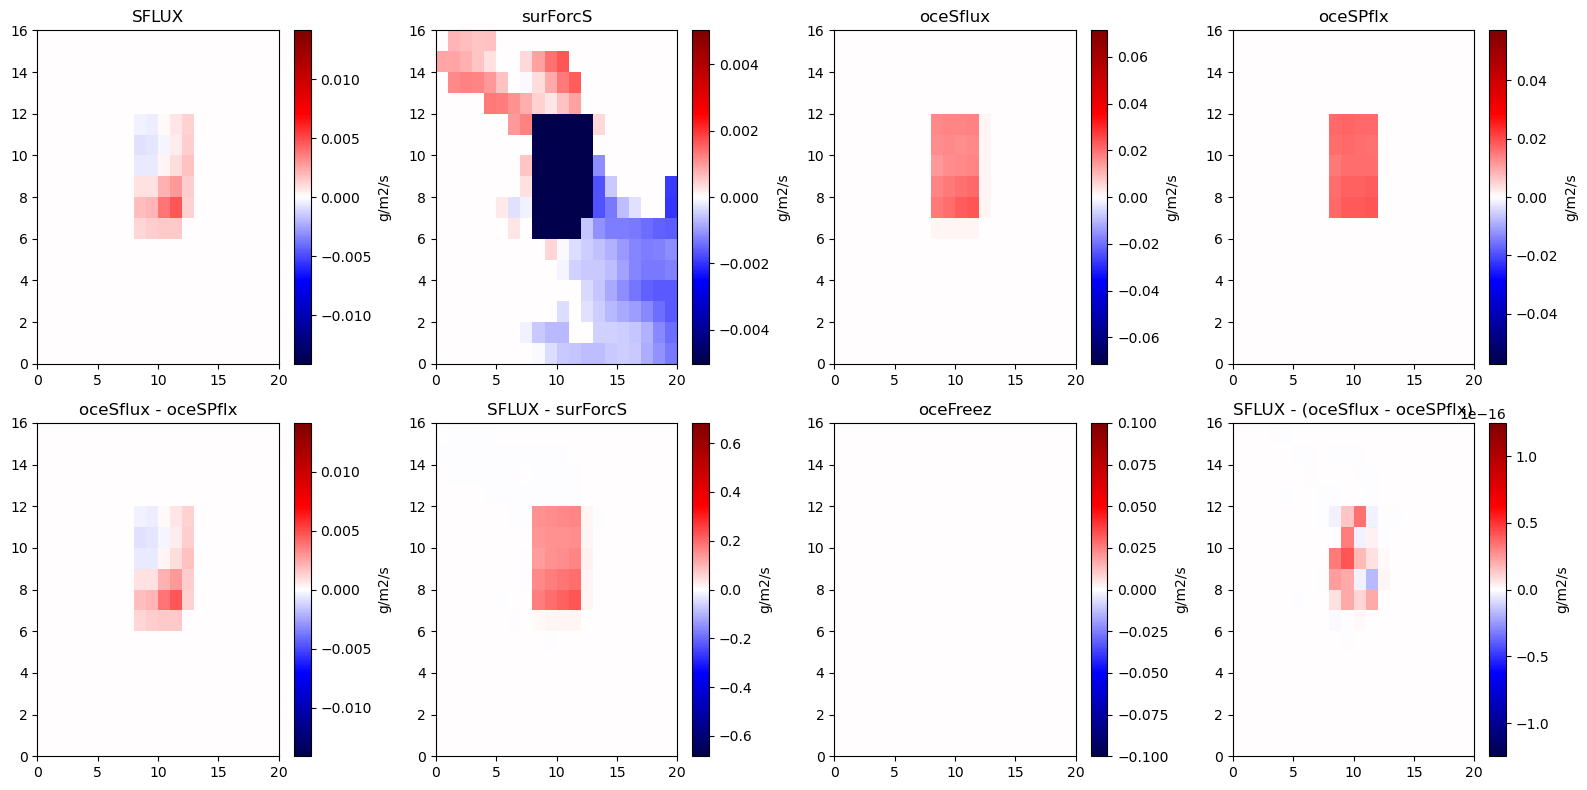

In [15]:
fig = plt.figure(figsize=(16, 8))

terms = {
    "SFLUX": SFLUX,
    "surForcS": surForcS,
    "oceSflux": oceSflux,
    "oceSPflx": oceSPflx,
    "oceSflux - oceSPflx": oceSflux - oceSPflx,
    "SFLUX - surForcS": SFLUX - surForcS,
    "oceFreez": oceFreez,
    "SFLUX - (oceSflux - oceSPflx)": SFLUX - (oceSflux - oceSPflx),
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(2, 4, n)
    vlev = get_vlev(fld)
    plt.pcolormesh(fld, cmap="seismic", vmin=-3*vlev, vmax=3*vlev)
    plt.colorbar(label="g/m2/s")
    plt.title(name)

plt.tight_layout()
plt.show()

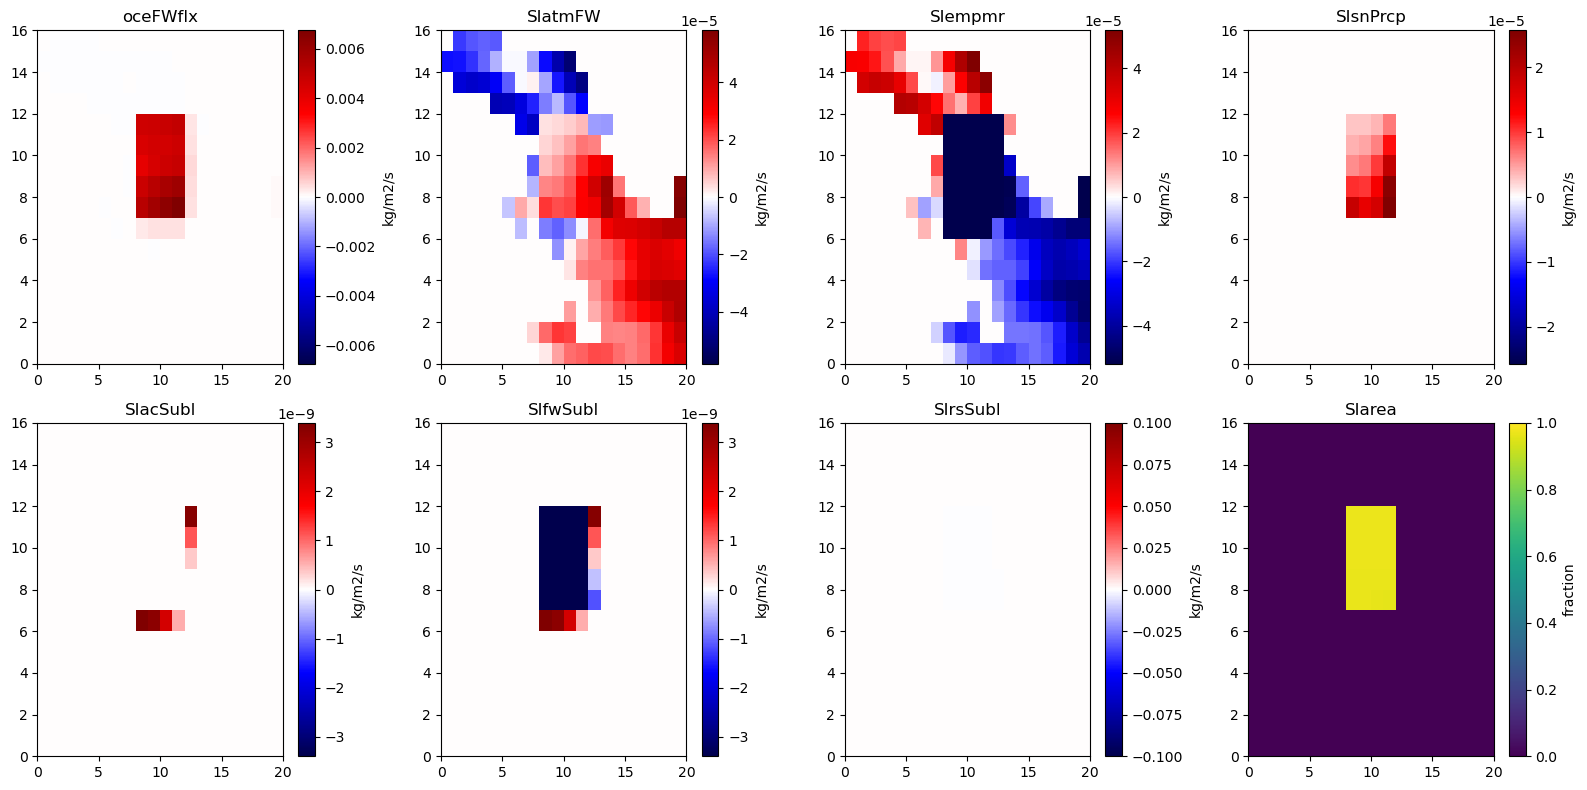

In [16]:
fig = plt.figure(figsize=(16, 8))

terms = {
    "oceFWflx": oceFWflx,
    "SIatmFW": SIatmFW,
    "SIempmr": SIempmr,
    "SIsnPrcp": SIsnPrcp,
    "SIacSubl": SIacSubl,
    "SIfwSubl": SIfwSubl,
    "SIrsSubl": SIrsSubl,
    "SIarea": SIarea,
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(2, 4, n)

    if name == "SIarea":
        plt.pcolormesh(fld, cmap="viridis", vmin=0, vmax=1)
        plt.colorbar(label="fraction")
    else:
        vlev = get_vlev(fld)
        plt.pcolormesh(fld, cmap="seismic", vmin=-vlev, vmax=vlev)
        plt.colorbar(label="kg/m2/s")

    plt.title(name)

plt.tight_layout()
plt.show()

In [17]:
## read in salt from STATE
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

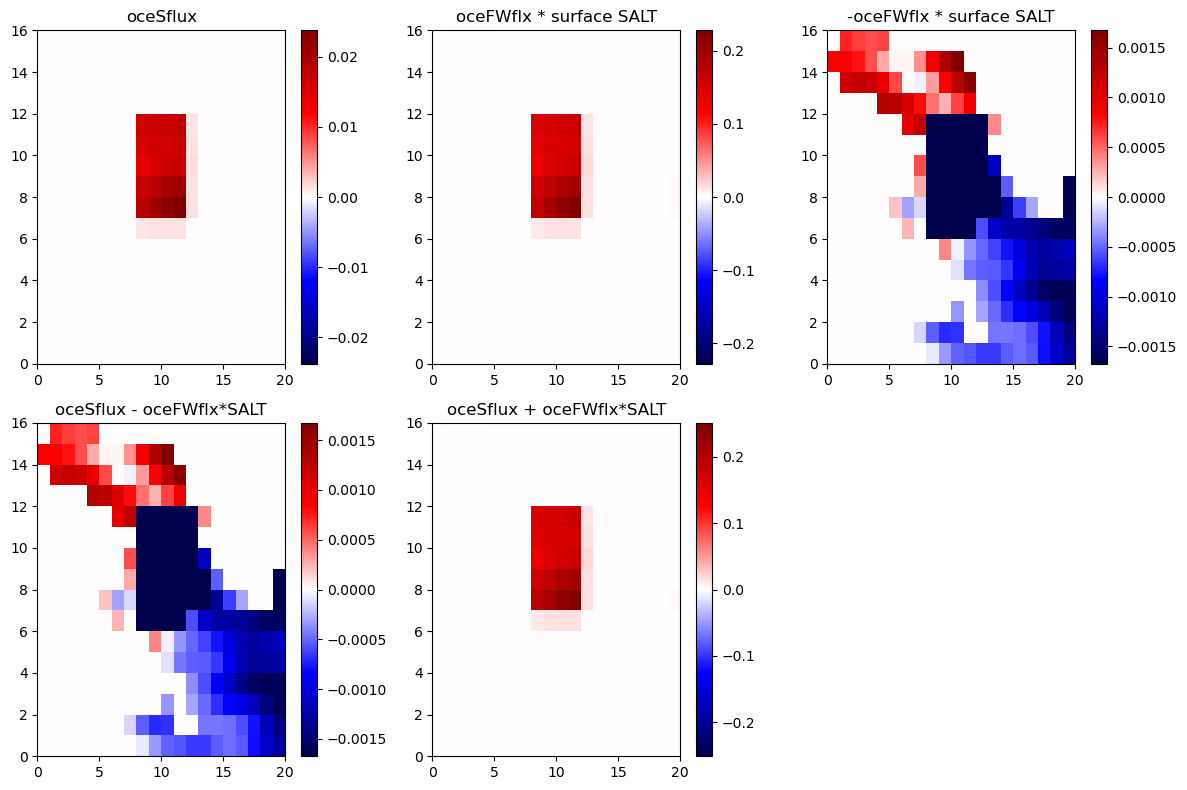

In [18]:
salt0 = SALT[0, :, :]   # or surface level depending orientation

test1 = oceFWflx * salt0
test2 = -oceFWflx * salt0

fig = plt.figure(figsize=(12, 8))

terms = {
    "oceSflux": oceSflux,
    "oceFWflx * surface SALT": test1,
    "-oceFWflx * surface SALT": test2,
    "oceSflux - oceFWflx*SALT": oceSflux - test1,
    "oceSflux + oceFWflx*SALT": oceSflux - test2,
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(2, 3, n)
    vlev = get_vlev(fld)
    plt.pcolormesh(fld, cmap="seismic", vmin=-vlev, vmax=vlev)
    plt.colorbar()
    plt.title(name)

plt.tight_layout()
plt.show()

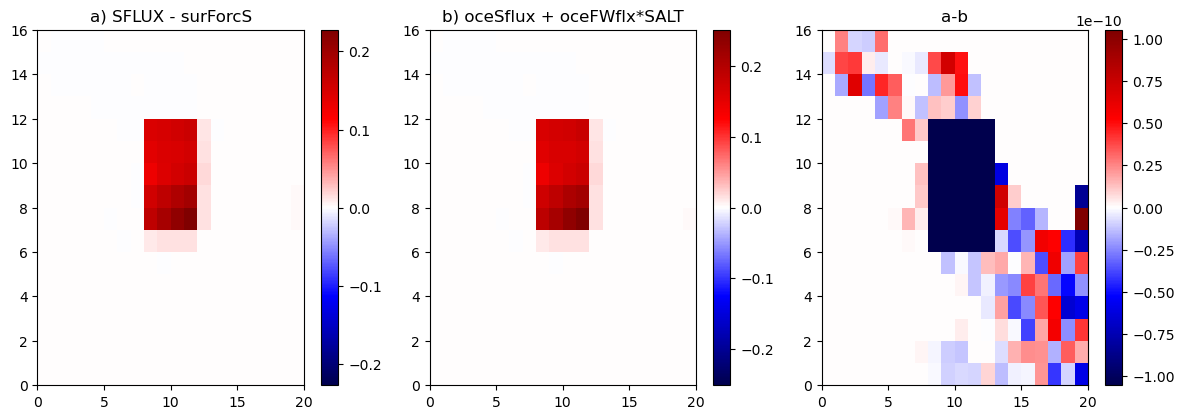

In [19]:
salt0 = SALT[0, :, :]   # or surface level depending orientation

test1 = oceFWflx * salt0
test2 = -oceFWflx * salt0

fig = plt.figure(figsize=(12, 8))


# plot a) SFLUX - surForcS, b) oceSflux + oceFWflx*SALT, then a-b
terms = {
    "a) SFLUX - surForcS": SFLUX - surForcS,
    "b) oceSflux + oceFWflx*SALT": oceSflux - test2,
    "a-b": (SFLUX - surForcS) - (oceSflux - test2),
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(2, 3, n)
    vlev = get_vlev(fld)
    plt.pcolormesh(fld, cmap="seismic", vmin=-vlev, vmax=vlev)
    plt.colorbar()
    plt.title(name)

plt.tight_layout()
plt.show()

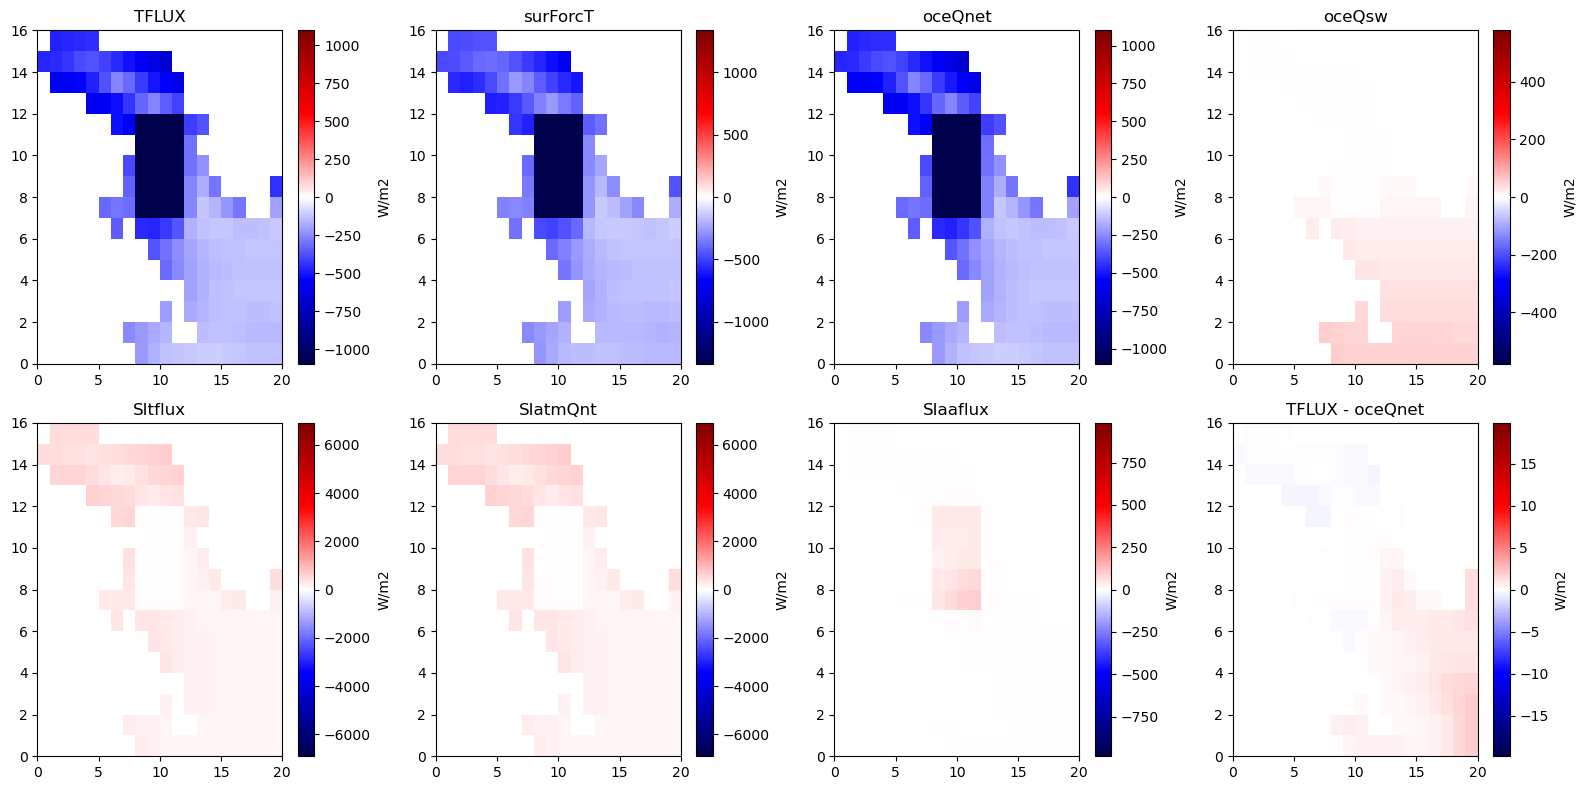

In [20]:
fig = plt.figure(figsize=(16, 8))

terms = {
    "TFLUX": TFLUX * mygrid['hFacC'][0],
    "surForcT": surForcT * mygrid['hFacC'][0],
    "oceQnet": oceQnet * mygrid['hFacC'][0],
    "oceQsw": oceQsw * mygrid['hFacC'][0],
    "SItflux": SItflux * mygrid['hFacC'][0],
    "SIatmQnt": SIatmQnt * mygrid['hFacC'][0],
    "SIaaflux": SIaaflux * mygrid['hFacC'][0],
    "TFLUX - oceQnet": (TFLUX - oceQnet - SIaaflux) * mygrid['hFacC'][0],
}

for n, (name, fld) in enumerate(terms.items(), start=1):
    ax = plt.subplot(2, 4, n)
    vlev = get_vlev(fld)
    plt.pcolormesh(fld, cmap="seismic", vmin=-10*vlev, vmax=10*vlev)
    plt.colorbar(label="W/m2")
    plt.title(name)

plt.tight_layout()
plt.show()

## try other help

In [21]:
from flux_breakdown_plot_options import *



budg2d_zflux_set1:
  available: oceFWflx, SIatmFW, TFLUX, SItflux, SFLUX, oceQsw, oceSPflx
budg2d_zflux_set2:
  available: WTHMASS, WSLTMASS, oceSflux, oceQnet, SIatmQnt, SIaaflux, SIsnPrcp, SIacSubl
flux_breakdown_extra_seaice:
  available: surForcT, surForcS, SIempmr, SIfwSubl, SIrsSubl, SIhl, SIqneto, SIqneti, oceFreez
flux_breakdown_extra_exf:
  available: EXFsnow
seaice_thermo_breakdown:
  available: SIfwSubl, SIacSubl, SIrsSubl, SIaQbOCN, SIaQbATC, SIaQbATO, SIdHbOCN, SIdHbATC, SIdHbATO, SIdHbFLO, SIdSbATC, SIdSbOCN, SIdAbATO
state_2d_set1:
  available: ETAN, SIarea, SIheff, SIhsnow, DETADT2, PHIBOT, sIceLoad, MXLDEPTH, SIatmQnt, SIatmFW, oceQnet, oceFWflx, oceTAUX, oceTAUY, ADVxHEFF, ADVyHEFF, ADVxSNOW, ADVySNOW, SIuice, SIvice, ETANSQ, oceSPDep
SFLUX: SFLUX: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX: surForcS: min=-2.230532e-01, mean=-2.292055e-02, max= 1.674536e-03, area_sum=-7.342262e+10
SFLUX: oceSflux: min= 0.000000e+00, mean= 2.

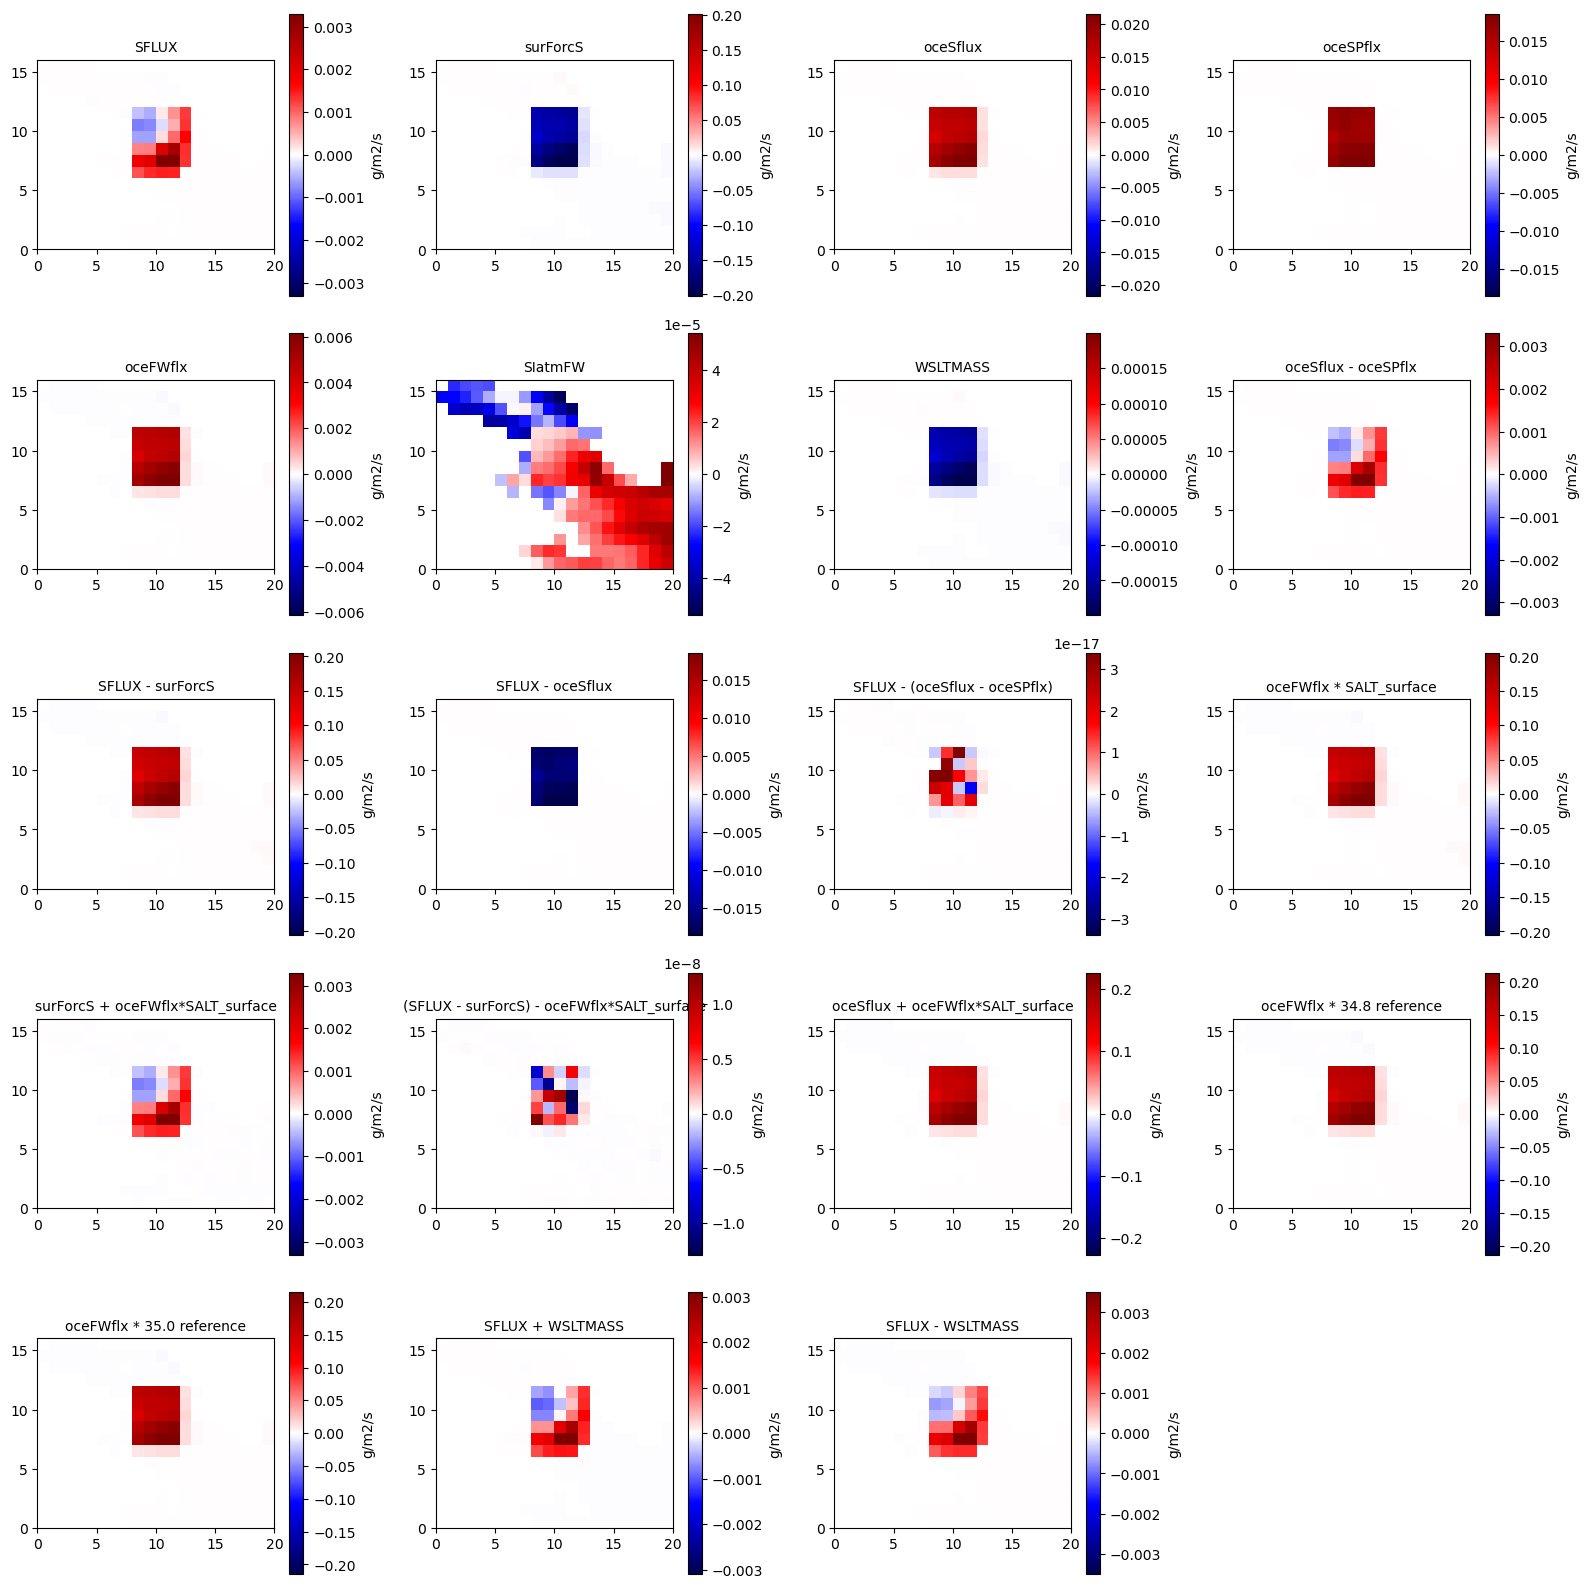

In [22]:
data = combine_diagnostic_dicts(budg1, budg2, extra_seaice, extra_exf, state2d)
print(available_diagnostic_text(data))

mask = mygrid["hFacC"][0]

sopts = mask_options(sflux_options(data, salt_surface=SALT[0]), mask)
plot_option_grid(sopts, units="g/m2/s", ncols=4)
print_integrals(sopts, area=mygrid["RAC"], label="SFLUX")

In [23]:
terms.keys()

dict_keys(['TFLUX', 'surForcT', 'oceQnet', 'oceQsw', 'SItflux', 'SIatmQnt', 'SIaaflux', 'TFLUX - oceQnet'])

(<Figure size 1600x640 with 16 Axes>,
 array([[<Axes: title={'center': 'TFLUX'}>,
         <Axes: title={'center': 'surForcT'}>,
         <Axes: title={'center': 'oceQnet'}>,
         <Axes: title={'center': 'oceQsw'}>],
        [<Axes: title={'center': 'SItflux'}>,
         <Axes: title={'center': 'SIatmQnt'}>,
         <Axes: title={'center': 'SIaaflux'}>,
         <Axes: title={'center': 'TFLUX - oceQnet'}>]], dtype=object))

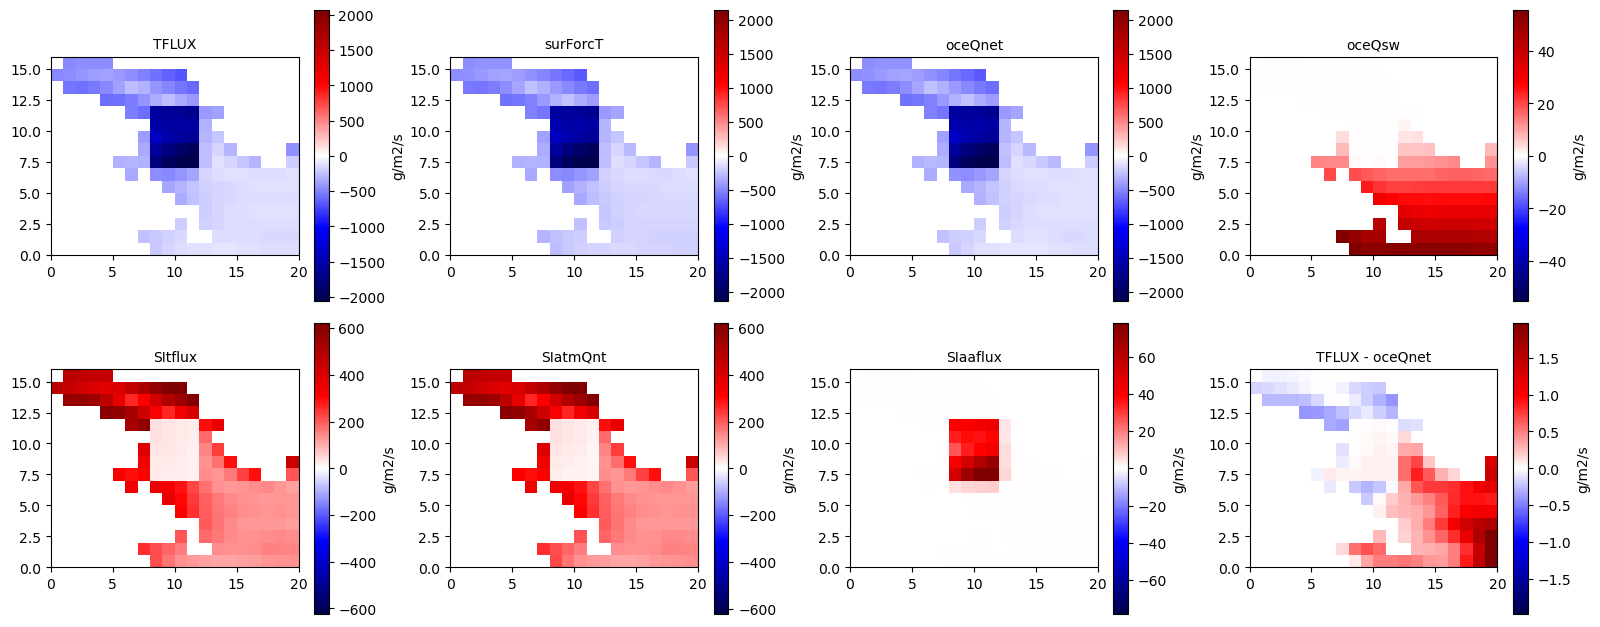

In [24]:
plot_option_grid(mask_options(terms, mygrid["hFacC"][0]), units="g/m2/s")
# print_integrals(mask_options(terms, mygrid["hFacC"][0]), area=mygrid["RAC"])

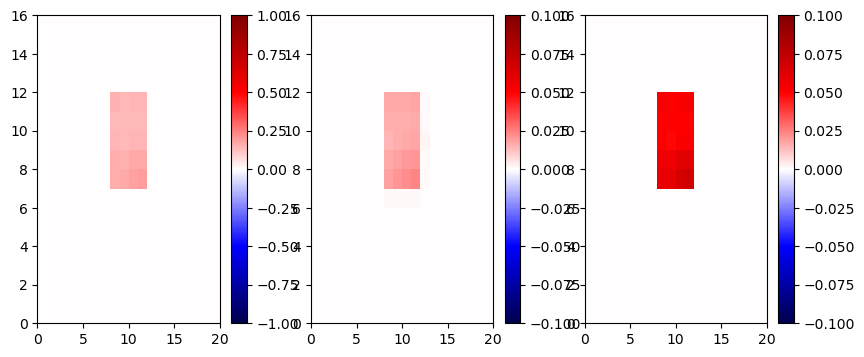

In [25]:
dSIheff  # m/s  - we want g/m^2/s -- * salt * rho = g/m/s/kg * kg/m^3 = g/m^2/s
a = dSIheff * SALT[0] * 917
b = dSIhsnow * SALT[0] * 917

fig = plt.figure()

ax = plt.subplot(131)
cb = ax.pcolormesh(-a,cmap='seismic',vmin=-1,vmax=1)
plt.colorbar(cb)

ax = plt.subplot(132)
cb = ax.pcolormesh(oceSflux,cmap='seismic',vmin=-.1,vmax=.1)
plt.colorbar(cb)

ax = plt.subplot(133)
cb = ax.pcolormesh(-b,cmap='seismic',vmin=-.1,vmax=.1)
plt.colorbar(cb)

In [26]:

# topts = mask_options(tflux_options(data, theta_surface=THETA[0]), mask)
# plot_option_grid(topts, units="W/m2", ncols=4)
# print_integrals(topts, area=mygrid["RAC"], label="TFLUX")

In [27]:
# load the fluxes

In [28]:
SSS = SALT[0]
rhoIce = 917
SEAICE_salt0 = 4  # PSU
SSS_eff = xr.where(SSS < SEAICE_salt0, SSS, SEAICE_salt0)

rhoIce = 917.0
SSS = SALT[0]

ocn = SIdHbOCN * SSS * rhoIce
atc = SIdHbATC * SSS * rhoIce
ato = SIdHbATO * SSS * rhoIce
flo = SIdHbFLO * SSS * rhoIce

breakdown_sum = ocn + atc + ato + flo
resid = oceSflux + breakdown_sum   # use + because you plot -component

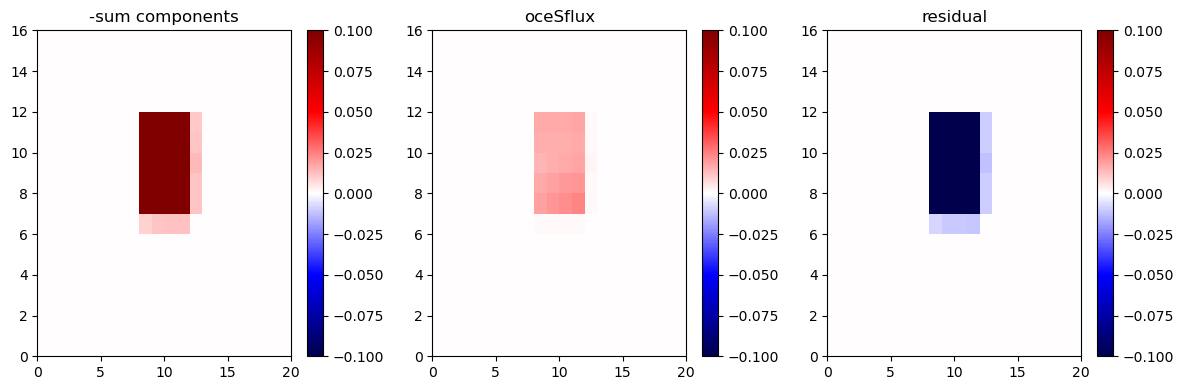

In [29]:
plt.figure(figsize=(12, 4))

ax = plt.subplot(131)
cb = ax.pcolormesh(-breakdown_sum, cmap="seismic", vmin=-0.1, vmax=0.1)
ax.set_title("-sum components")
plt.colorbar(cb)

ax = plt.subplot(132)
cb = ax.pcolormesh(oceSflux, cmap="seismic", vmin=-0.1, vmax=0.1)
ax.set_title("oceSflux")
plt.colorbar(cb)

ax = plt.subplot(133)
cb = ax.pcolormesh(oceSflux + breakdown_sum, cmap="seismic", vmin=-0.1, vmax=0.1)
ax.set_title("residual")
plt.colorbar(cb)

plt.tight_layout()

## Clean SFLUX and dHEFF breakdown plots

These cells use the Fortran relationships directly:

`SFLUX = surForcS + oceFWflx*SALT_surface`

`SFLUX = oceSflux - oceSPflx`

Then they test how much of `oceSflux` can be reconstructed from the loaded `SIdHb*` sea-ice thickness-rate diagnostics.


In [30]:
import importlib
import flux_breakdown_plot_options as fbpo
importlib.reload(fbpo)
from flux_breakdown_plot_options import *

mask = mygrid["hFacC"][0]
area = mygrid["RAC"] * mask
salt_surface = SALT[0]

data = combine_diagnostic_dicts(budg1, budg2, extra_seaice, extra_exf, state2d)
print(available_diagnostic_text(data))


budg2d_zflux_set1:
  available: oceFWflx, SIatmFW, TFLUX, SItflux, SFLUX, oceQsw, oceSPflx
budg2d_zflux_set2:
  available: WTHMASS, WSLTMASS, oceSflux, oceQnet, SIatmQnt, SIaaflux, SIsnPrcp, SIacSubl
flux_breakdown_extra_seaice:
  available: surForcT, surForcS, SIempmr, SIfwSubl, SIrsSubl, SIhl, SIqneto, SIqneti, oceFreez
flux_breakdown_extra_exf:
  available: EXFsnow
seaice_thermo_breakdown:
  available: SIfwSubl, SIacSubl, SIrsSubl, SIaQbOCN, SIaQbATC, SIaQbATO, SIdHbOCN, SIdHbATC, SIdHbATO, SIdHbFLO, SIdSbATC, SIdSbOCN, SIdAbATO
state_2d_set1:
  available: ETAN, SIarea, SIheff, SIhsnow, DETADT2, PHIBOT, sIceLoad, MXLDEPTH, SIatmQnt, SIatmFW, oceQnet, oceFWflx, oceTAUX, oceTAUY, ADVxHEFF, ADVyHEFF, ADVxSNOW, ADVySNOW, SIuice, SIvice, ETANSQ, oceSPDep


SFLUX exact closure: SFLUX: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX exact closure: surForcS: min=-2.230532e-01, mean=-2.292055e-02, max= 1.674536e-03, area_sum=-7.342262e+10
SFLUX exact closure: oceSflux: min= 0.000000e+00, mean= 2.464879e-03, max= 2.376252e-02, area_sum= 7.815183e+09
SFLUX exact closure: oceSPflx: min= 0.000000e+00, mean= 2.265432e-03, max= 1.905216e-02, area_sum= 7.114653e+09
SFLUX exact closure: oceFWflx: min=-5.182153e-05, mean= 7.065689e-04, max= 6.747317e-03, area_sum= 2.261362e+09
SFLUX exact closure: SIempmr: min=-6.747317e-03, mean=-7.065689e-04, max= 5.182153e-05, area_sum=-2.261362e+09
SFLUX exact closure: SIatmFW: min=-5.182153e-05, mean= 9.766682e-06, max= 5.807607e-05, area_sum= 5.206931e+07
SFLUX exact closure: ice salt to ocean: oceSflux - oceSPflx: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX exact closure: real FW salt advection: oceFWflx*SALT: min=-1.674536e-03, 

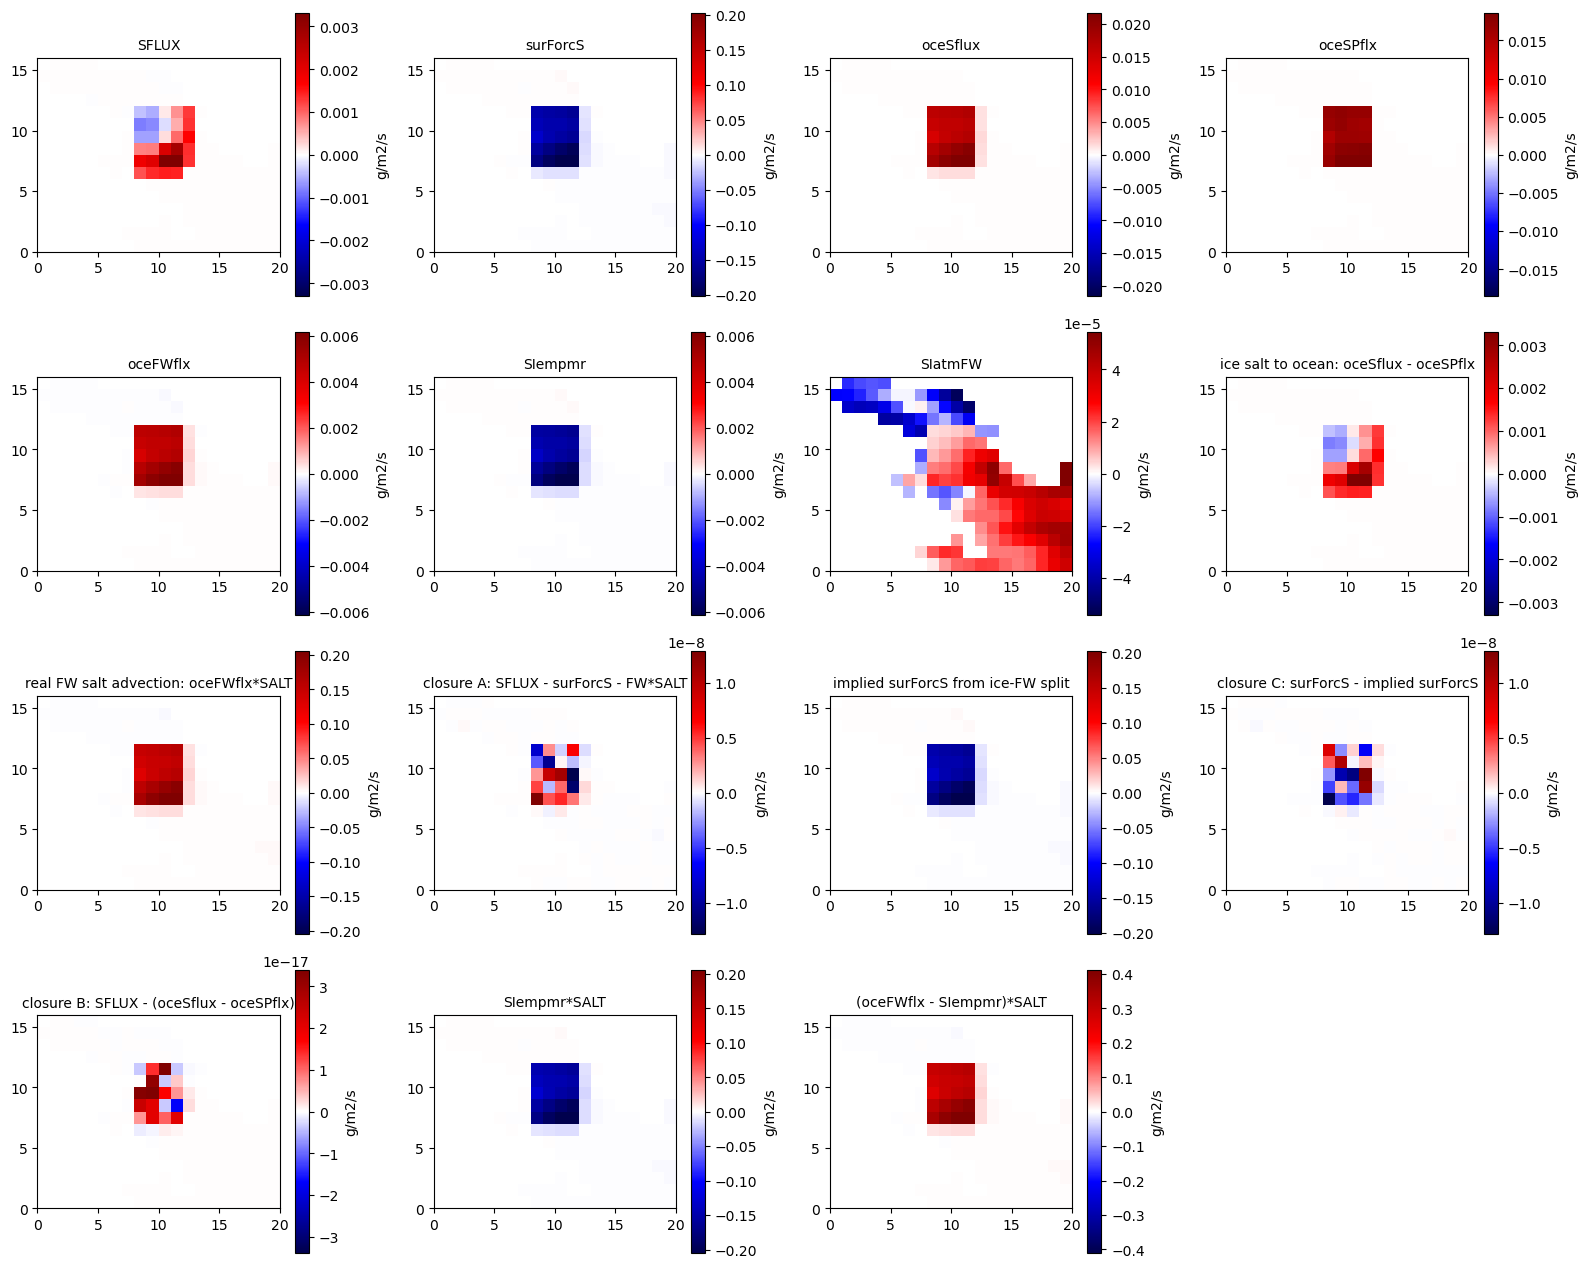

In [31]:
# Exact SFLUX closures from diags_oceanic_surf_flux.F and external_forcing_surf.F.
# The residuals here should be near numerical precision if the same time record is used.
closure_terms = sflux_closure_breakdown(data, salt_surface=salt_surface)
closure_terms = mask_options(closure_terms, mask)

plot_option_grid(closure_terms, units="g/m2/s", ncols=4, robust_pct=99.0)
print_integrals(closure_terms, area=area, label="SFLUX exact closure")


dHEFF salt reconstruction: saltFlux component SIdHbOCN: min=-2.730538e-02, mean=-2.840051e-03, max= 0.000000e+00, area_sum=-8.998826e+09
dHEFF salt reconstruction: oceSflux component SIdHbOCN: min=-0.000000e+00, mean= 2.840051e-03, max= 2.730538e-02, area_sum= 8.998826e+09
dHEFF salt reconstruction: saltFlux component SIdHbATC: min= 0.000000e+00, mean= 1.688155e-05, max= 1.978057e-04, area_sum= 5.134399e+07
dHEFF salt reconstruction: oceSflux component SIdHbATC: min=-1.978057e-04, mean=-1.688155e-05, max=-0.000000e+00, area_sum=-5.134399e+07
dHEFF salt reconstruction: saltFlux component SIdHbATO: min= 0.000000e+00, mean= 1.946893e-05, max= 2.318140e-04, area_sum= 6.017382e+07
dHEFF salt reconstruction: oceSflux component SIdHbATO: min=-2.318140e-04, mean=-1.946893e-05, max=-0.000000e+00, area_sum=-6.017382e+07
dHEFF salt reconstruction: saltFlux component SIdHbFLO: min= 0.000000e+00, mean= 3.198729e-04, max= 3.234882e-03, area_sum= 1.012051e+09
dHEFF salt reconstruction: oceSflux compo

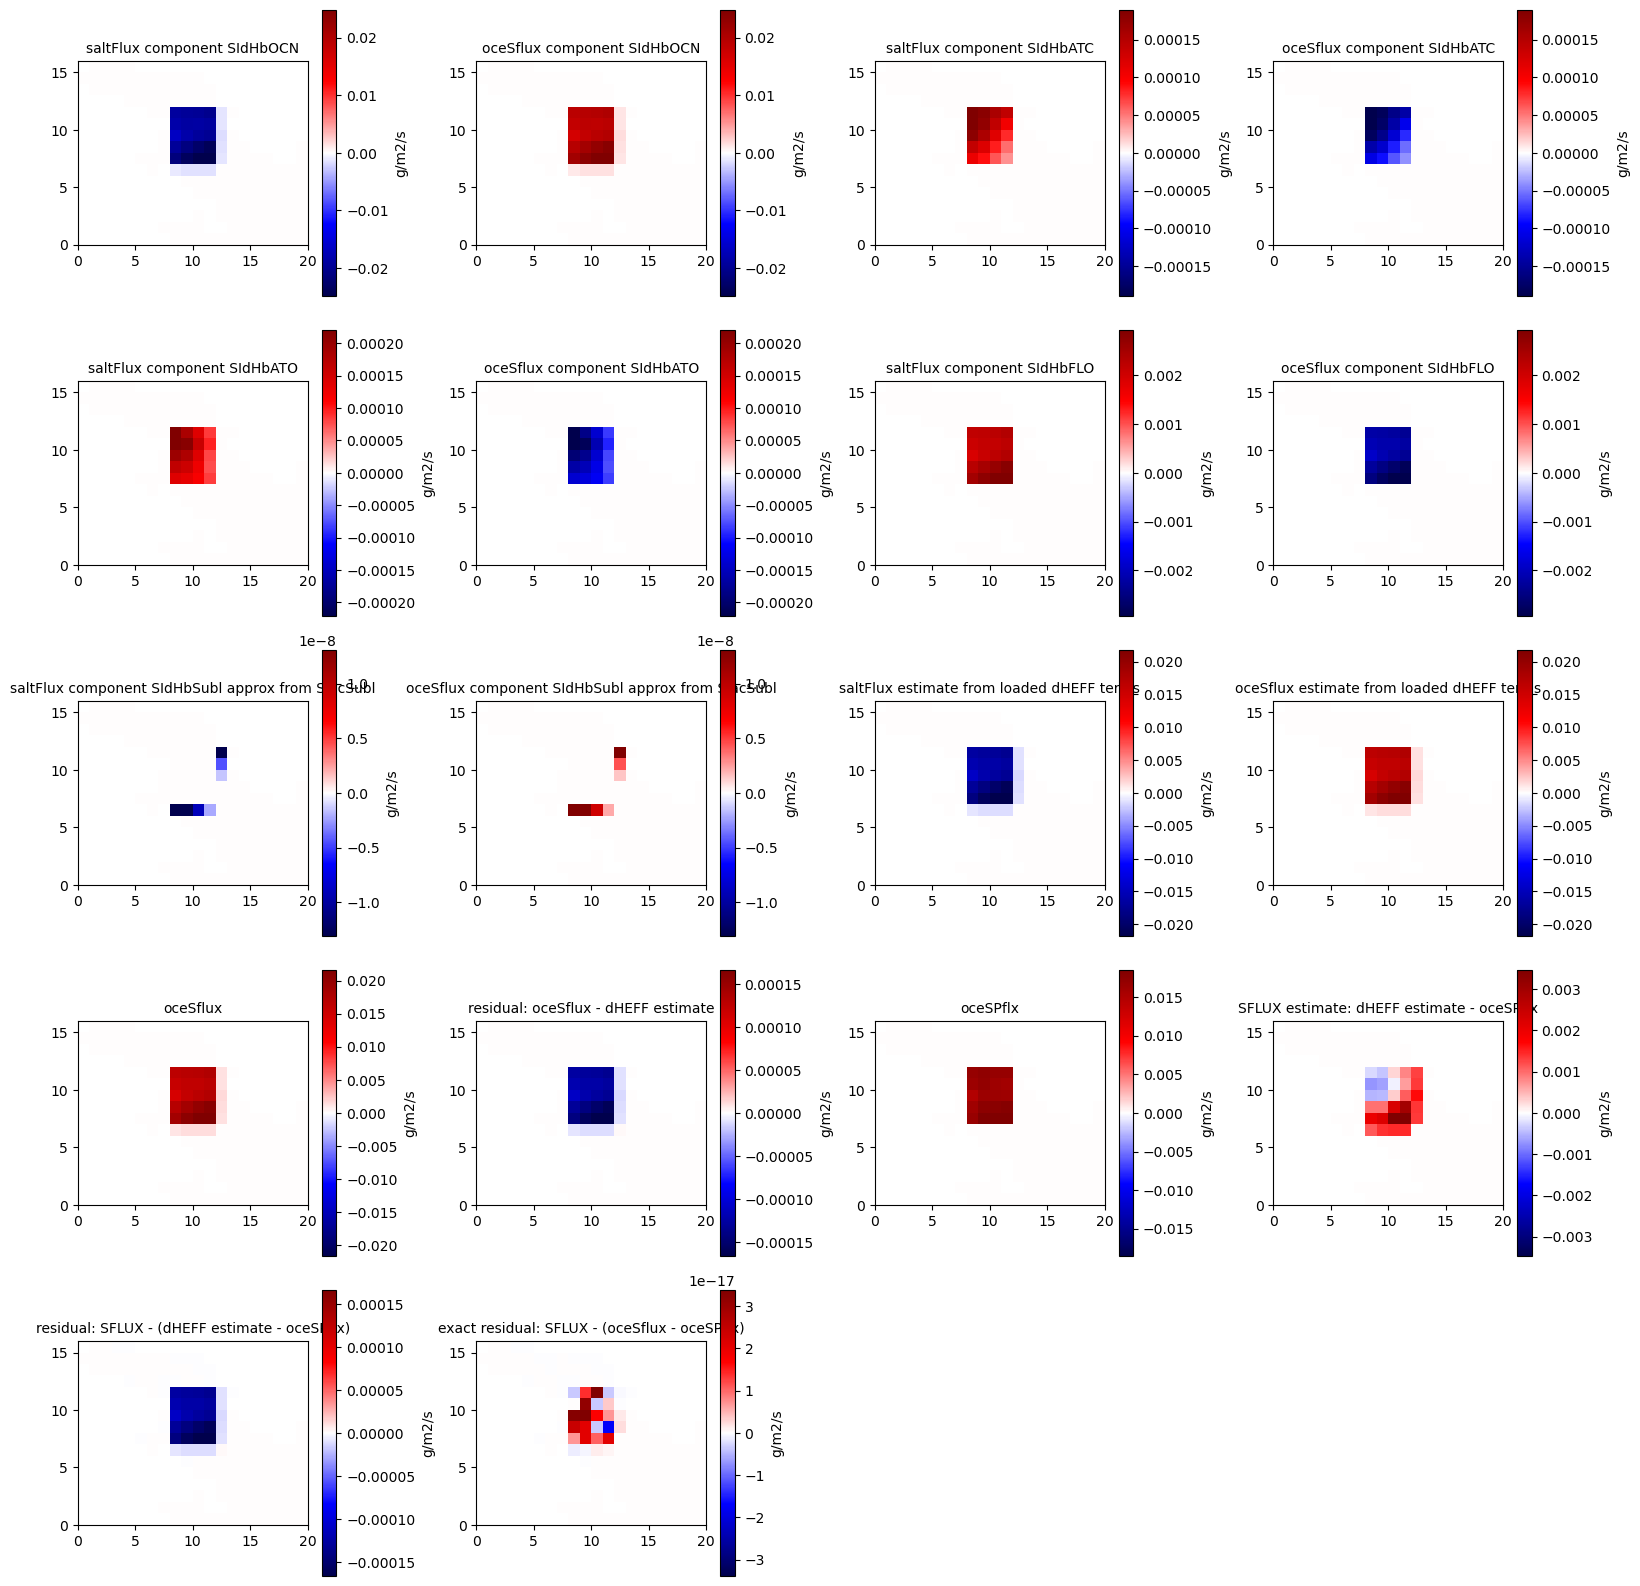

In [32]:
# Partial reconstruction of oceSflux from loaded sea-ice thermodynamic dHEFF diagnostics.
# SIdHb* are d_HEFF/dt [m/s].  Convert to salt flux using min(SEAICE_salt0, SSS)*rhoIce.
# This is partial: d_HEFFbyNEG, d_HEFFbySublim, optional d_HEFFbyRLX, and saltFluxAdjust
# are not fully available as SIdHb* fields in the current output.
rhoIce = 917.0
SEAICE_salt0 = 4.0

sice = np.maximum(0.0, np.minimum(SEAICE_salt0, salt_surface))
dheff_terms = sflux_dheff_breakdown(
    data,
    salt_surface=salt_surface,
    seaice_salt0=SEAICE_salt0,
    rho_ice=rhoIce,
    include_sublimation_approx=True,
)
dheff_terms = mask_options(dheff_terms, mask)

plot_option_grid(dheff_terms, units="g/m2/s", ncols=4, robust_pct=99.0)
print_integrals(dheff_terms, area=area, label="dHEFF salt reconstruction")


SFLUX interpretation: SFLUX exact: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX interpretation: oceSflux - oceSPflx: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX interpretation: dHEFF estimate - oceSPflx: min=-7.198091e-04, mean= 2.183967e-04, max= 4.893147e-03, area_sum= 7.606063e+08
SFLUX interpretation: SFLUX - exact ice salt: min=-1.734723e-17, mean= 1.731742e-18, max= 4.163336e-17, area_sum= 5.510773e-06
SFLUX interpretation: SFLUX - partial dHEFF estimate: min=-1.827886e-04, mean=-1.894984e-05, max= 1.659249e-06, area_sum=-6.007552e+07
SFLUX interpretation: oceSflux - dHEFF estimate: min=-1.827886e-04, mean=-1.894984e-05, max= 1.659249e-06, area_sum=-6.007552e+07
SFLUX interpretation: oceSPflx: min= 0.000000e+00, mean= 2.265432e-03, max= 1.905216e-02, area_sum= 7.114653e+09
SFLUX interpretation: FW salt advection: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10


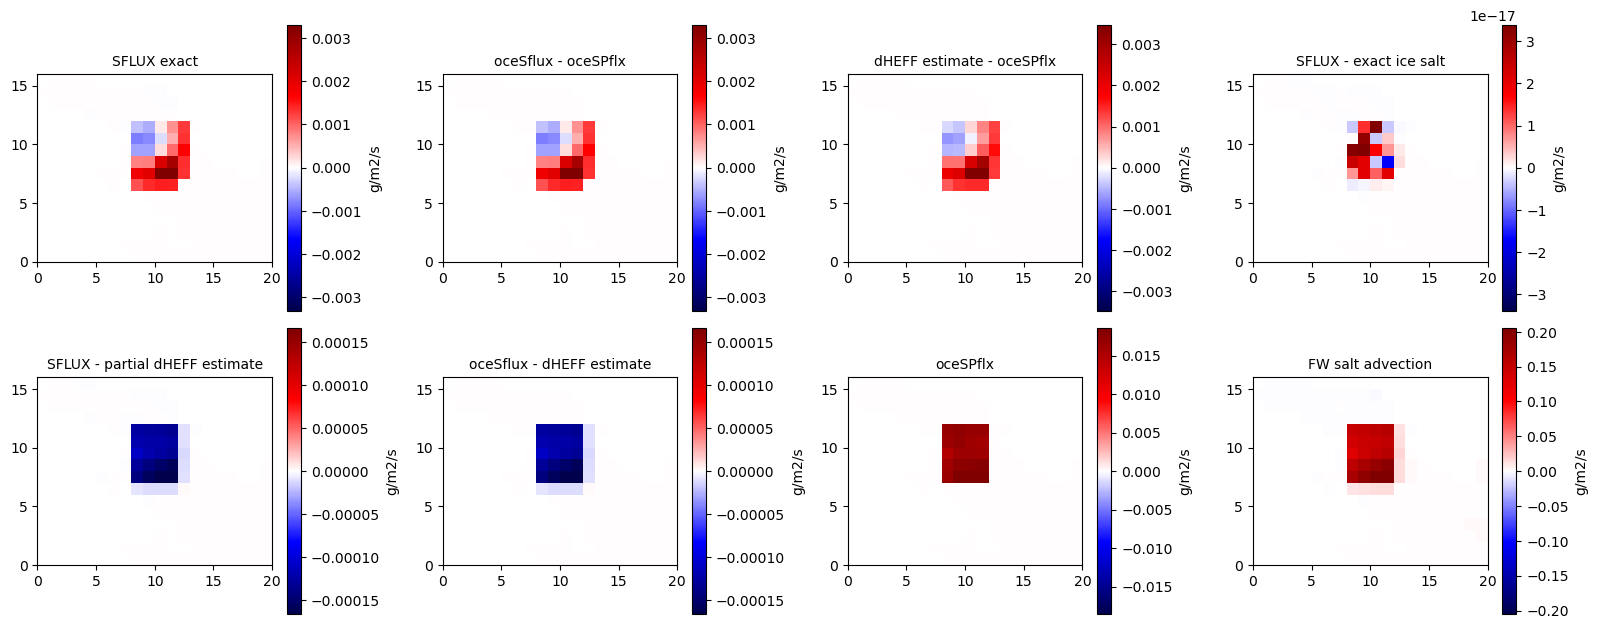

In [33]:
# A tighter panel for interpretation: compare exact SFLUX pieces against the dHEFF estimate.
dheff_est = dheff_terms["oceSflux estimate from loaded dHEFF terms"]
exact_ice_salt = (oceSflux - oceSPflx) * mask
partial_sflux_est = (dheff_est - oceSPflx * mask)

compare_terms = {
    "SFLUX exact": SFLUX * mask,
    "oceSflux - oceSPflx": exact_ice_salt,
    "dHEFF estimate - oceSPflx": partial_sflux_est,
    "SFLUX - exact ice salt": (SFLUX - (oceSflux - oceSPflx)) * mask,
    "SFLUX - partial dHEFF estimate": (SFLUX * mask) - partial_sflux_est,
    "oceSflux - dHEFF estimate": (oceSflux * mask) - dheff_est,
    "oceSPflx": oceSPflx * mask,
    "FW salt advection": (oceFWflx * salt_surface) * mask,
}

plot_option_grid(compare_terms, units="g/m2/s", ncols=4, robust_pct=99.0)
print_integrals(compare_terms, area=area, label="SFLUX interpretation")


In [34]:
dheff_est.shape

(16, 20)

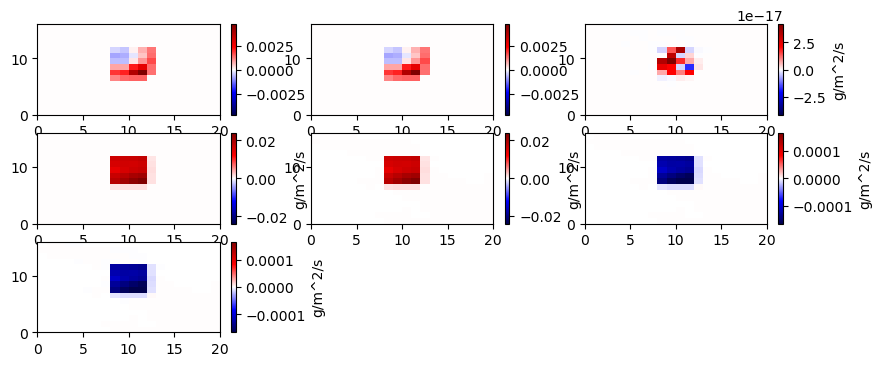

In [35]:
fig = plt.figure()

ax = plt.subplot(331)
vlev = get_vlev(SFLUX)
cb = ax.pcolormesh(SFLUX,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(332)
vlev = get_vlev(oceSflux - oceSPflx)
cb = ax.pcolormesh(oceSflux - oceSPflx,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(333)
vlev = get_vlev(SFLUX - oceSflux + oceSPflx)
cb = ax.pcolormesh(SFLUX - oceSflux + oceSPflx,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(334)
vlev = get_vlev(oceSflux)
cb = ax.pcolormesh(oceSflux,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(335)
vlev = get_vlev(dheff_est)
cb = ax.pcolormesh(dheff_est,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(336)
vlev = get_vlev(oceSflux - dheff_est)
cb = ax.pcolormesh(oceSflux - dheff_est,cmap='seismic',vmin=-100*vlev,vmax=100*vlev)
plt.colorbar(cb,label="g/m^2/s")

ax = plt.subplot(337)
vlev = get_vlev(SFLUX - dheff_est + oceSPflx)
cb = ax.pcolormesh(SFLUX - dheff_est + oceSPflx,cmap='seismic',vmin=-100*vlev,vmax=100*vlev)
plt.colorbar(cb,label="g/m^2/s")

### Residual as missing dHEFF-equivalent

Because `SFLUX = oceSflux - oceSPflx` closes exactly, the residual in the last panel is not a new `SFLUX` term. It is the part of `oceSflux = -saltFlux` not explained by the loaded `SIdHb*` terms. This converts it back to an equivalent missing sea-ice thickness-rate term.


missing salt flux: oceSflux - dHEFF estimate: min=-1.827886e-04, mean=-1.894984e-05, max= 1.659249e-06, area_sum=-6.007552e+07


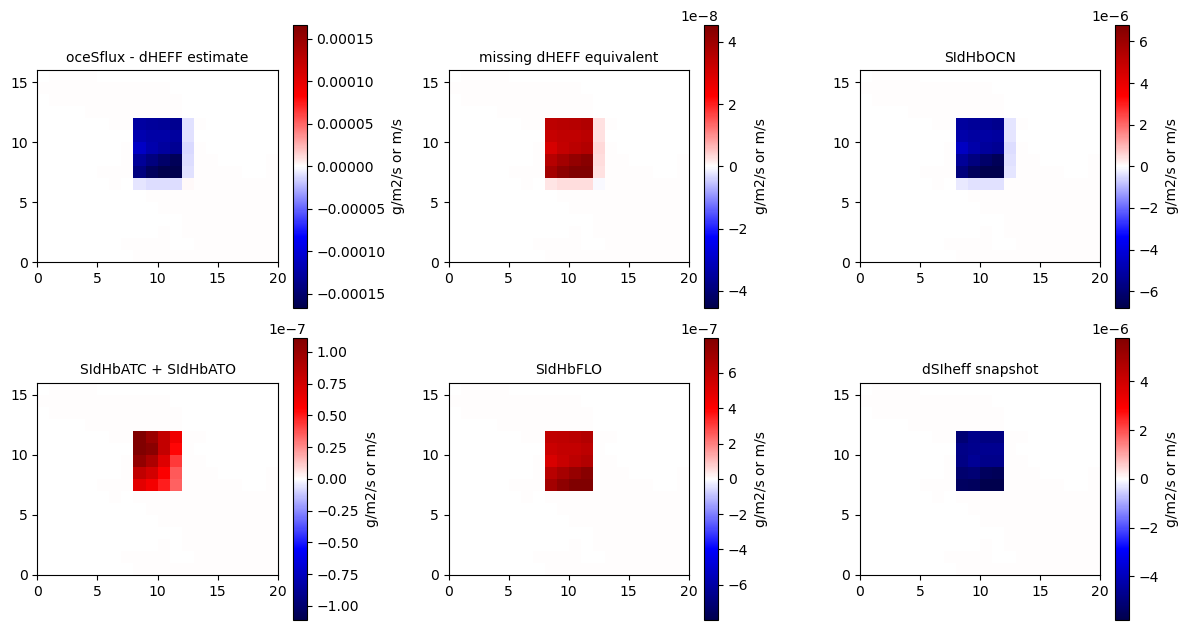

In [36]:
resid_oceSflux = oceSflux - dheff_est
missing_dheff_equiv = np.full_like(resid_oceSflux, np.nan)
valid = np.isfinite(sice) & (sice > 0) & np.isfinite(mask) & (mask > 0)
missing_dheff_equiv[valid] = -resid_oceSflux[valid] / (sice[valid] * rhoIce)

terms_missing = {
    "oceSflux - dHEFF estimate": resid_oceSflux * mask,
    "missing dHEFF equivalent": missing_dheff_equiv * mask,
    "SIdHbOCN": SIdHbOCN * mask,
    "SIdHbATC + SIdHbATO": (SIdHbATC + SIdHbATO) * mask,
    "SIdHbFLO": SIdHbFLO * mask,
    "dSIheff snapshot": dSIheff * mask,
}

plot_option_grid(terms_missing, units="g/m2/s or m/s", ncols=3, robust_pct=99.0)
print_integrals({"oceSflux - dHEFF estimate": resid_oceSflux * mask}, area=area, label="missing salt flux")


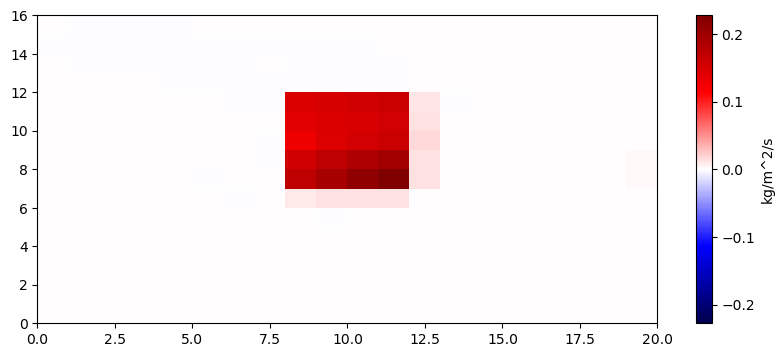

In [37]:
fig = plt.figure()
ax = plt.subplot(111)
vlev = get_vlev(oceFWflx * SALT[0])
cb = ax.pcolormesh(oceFWflx * SALT[0],cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="kg/m^2/s")

/tmp/ipykernel_2458540/1282048478.py:4: RuntimeWarning: divide by zero encountered in divide
  ratio = resid / (-SIdHbOCN * sice * 917.0)
/tmp/ipykernel_2458540/1282048478.py:4: RuntimeWarning: invalid value encountered in divide
  ratio = resid / (-SIdHbOCN * sice * 917.0)


(<Figure size 800x640 with 8 Axes>,
 array([[<Axes: title={'center': 'resid'}>,
         <Axes: title={'center': '-SIdHbOCN*sice*rhoIce'}>],
        [<Axes: title={'center': 'ratio'}>,
         <Axes: title={'center': 'SIdHbOCN'}>]], dtype=object))

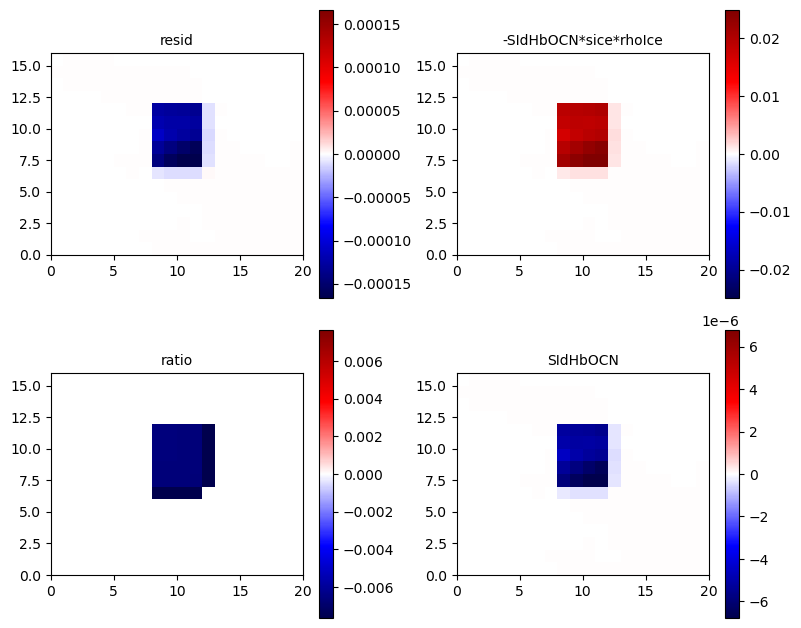

In [38]:
sice = np.maximum(0, np.minimum(4.0, SALT[0]))
resid = oceSflux - dheff_est

ratio = resid / (-SIdHbOCN * sice * 917.0)

terms = {
  "resid": resid * mask,
  "-SIdHbOCN*sice*rhoIce": (-SIdHbOCN * sice * 917.0) * mask,
  "ratio": ratio * mask,
  "SIdHbOCN": SIdHbOCN * mask,
}

plot_option_grid(terms, units="", ncols=2, robust_pct=99)

### EXF evap/SIarea freshwater path

`EVAP`, `PRECIP`, and `AREApreTH` enter the freshwater flux `EmPmR`, not `oceSflux` directly. This block reads the EXF flux diagnostics and compares the open-water atmospheric piece with `oceFWflx` and with the salt-advection term that appears in `SFLUX - surForcS`.


FW path: open water 1-SIarea: min= 2.865636e-02, mean= 8.709080e-01, max= 1.000000e+00, area_sum= 3.158412e+12
FW path: EXFempmr: min=-5.807607e-08, mean=-7.749365e-09, max= 5.182153e-08, area_sum=-4.547118e+04
FW path: open kg: (evap-precip-runoff)*(1-SIarea)*rho: min=-5.807607e-05, mean=-7.882275e-06, max= 5.182153e-05, area_sum=-4.588784e+07
FW path: -open kg: min=-5.182153e-05, mean= 7.882275e-06, max= 5.807607e-05, area_sum= 4.588784e+07
FW path: oceFWflx: min=-5.182153e-05, mean= 7.065689e-04, max= 6.747317e-03, area_sum= 2.261362e+09
FW path: SIempmr: min=-6.747317e-03, mean=-7.065689e-04, max= 5.182153e-05, area_sum=-2.261362e+09
FW path: SIatmFW: min=-5.182153e-05, mean= 9.766682e-06, max= 5.807607e-05, area_sum= 5.206931e+07
FW path: oceFWflx - (-open kg): min=-2.480372e-12, mean= 6.986866e-04, max= 6.746303e-03, area_sum= 2.215474e+09


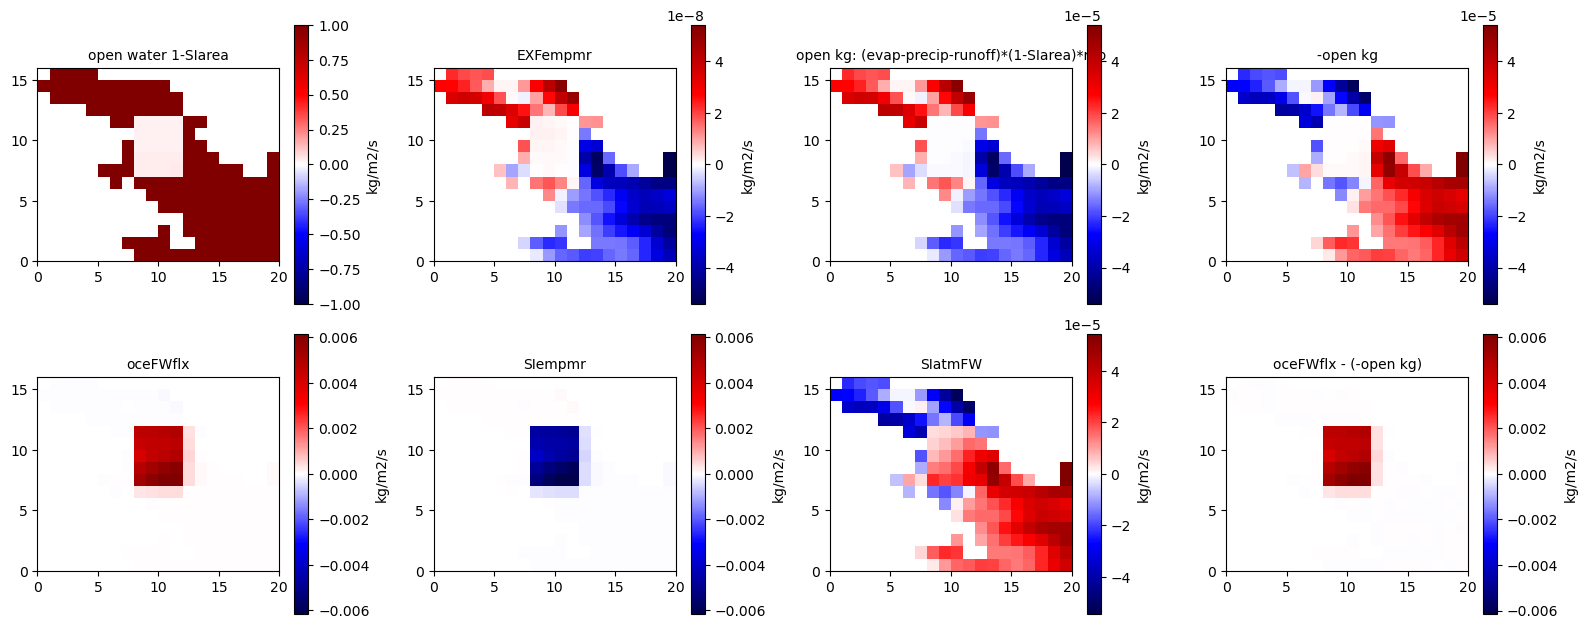

In [39]:
exf = read_all_2d_diags(direxf, "exf_zflux_set1", t2, tsstr, ny, nx)
EXFevap = exf.get("EXFevap")
EXFpreci = exf.get("EXFpreci")
EXFroff = exf.get("EXFroff")
EXFempmr = exf.get("EXFempmr")

open_water = 1.0 - SIarea
rhoFresh = 1000.0

# EXF evap/precip diagnostics are usually in m/s; multiply by rhoFresh to compare with kg/m2/s.
open_fw_kg = (EXFevap - EXFpreci - EXFroff) * open_water * rhoFresh
open_fw_down_kg = -open_fw_kg

fw_terms = {
    "open water 1-SIarea": open_water,
    "EXFempmr": EXFempmr,
    "open kg: (evap-precip-runoff)*(1-SIarea)*rho": open_fw_kg,
    "-open kg": open_fw_down_kg,
    "oceFWflx": oceFWflx,
    "SIempmr": SIempmr,
    "SIatmFW": SIatmFW,
    "oceFWflx - (-open kg)": oceFWflx - open_fw_down_kg,
}

plot_option_grid(mask_options(fw_terms, mask), units="kg/m2/s", ncols=4, robust_pct=99.0)
print_integrals(mask_options(fw_terms, mask), area=area, label="FW path")


FW salt path: SFLUX - surForcS: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
FW salt path: oceFWflx*SALT: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
FW salt path: -open kg*SALT: min=-1.674536e-03, mean= 2.768927e-04, max= 1.995078e-03, area_sum= 1.575950e+09
FW salt path: remaining FW salt: (oceFWflx + open kg)*SALT: min=-7.856328e-11, mean= 2.284311e-02, max= 2.277293e-01, area_sum= 7.254720e+10
FW salt path: exact residual: min=-7.814929e-09, mean= 1.310728e-10, max= 8.220781e-09, area_sum= 4.966928e+02


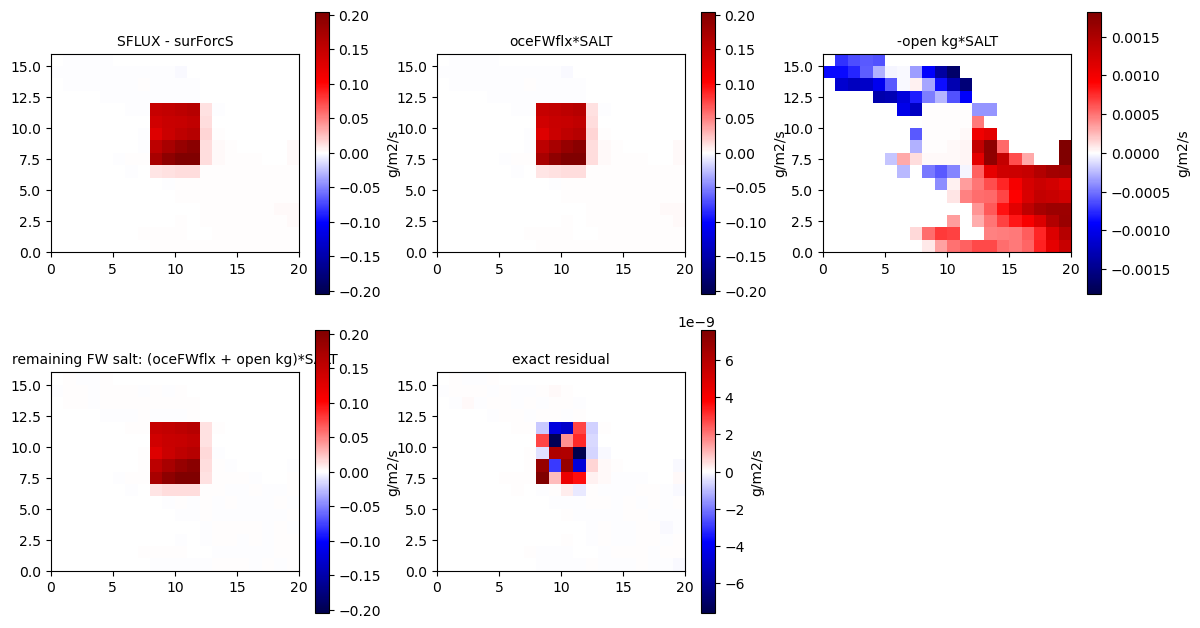

In [40]:
salt_fw_terms = {
    "SFLUX - surForcS": (SFLUX - surForcS) * mask,
    "oceFWflx*SALT": (oceFWflx * salt_surface) * mask,
    "-open kg*SALT": (open_fw_down_kg * salt_surface) * mask,
    "remaining FW salt: (oceFWflx + open kg)*SALT": ((oceFWflx - open_fw_down_kg) * salt_surface) * mask,
    "exact residual": ((SFLUX - surForcS) - oceFWflx * salt_surface) * mask,
}

plot_option_grid(salt_fw_terms, units="g/m2/s", ncols=3, robust_pct=99.0)
print_integrals(salt_fw_terms, area=area, label="FW salt path")


FW split: oceFWflx diagnostic: min=-5.182153e-05, mean= 7.065689e-04, max= 6.747317e-03, area_sum= 2.261362e+09
FW split: FW_E_down = -EXFevap*(1-SIarea)*rhoFresh: min=-5.862348e-05, mean=-2.259252e-05, max=-1.220400e-08, area_sum=-7.857391e+07
FW split: FW_P_down = EXFpreci*(1-SIarea)*rhoFresh: min= 8.989499e-08, mean= 3.047480e-05, max= 1.039183e-04, area_sum= 1.244618e+08
FW split: FW_R_down = EXFroff*rhoFresh: min= 0.000000e+00, mean= 0.000000e+00, max= 0.000000e+00, area_sum= 0.000000e+00
FW split: FW_EPR_down = E+P+R: min=-5.182153e-05, mean= 7.882275e-06, max= 5.807607e-05, area_sum= 4.588784e+07
FW split: FW_ice_down = oceFWflx - FW_EPR_down: min=-2.480372e-12, mean= 6.986866e-04, max= 6.746303e-03, area_sum= 2.215474e+09
FW split: FW residual = oceFWflx - EPR - ice: min= 0.000000e+00, mean= 0.000000e+00, max= 0.000000e+00, area_sum= 0.000000e+00
FW split: SIarea: min= 0.000000e+00, mean= 1.290920e-01, max= 9.713436e-01, area_sum= 4.041162e+11


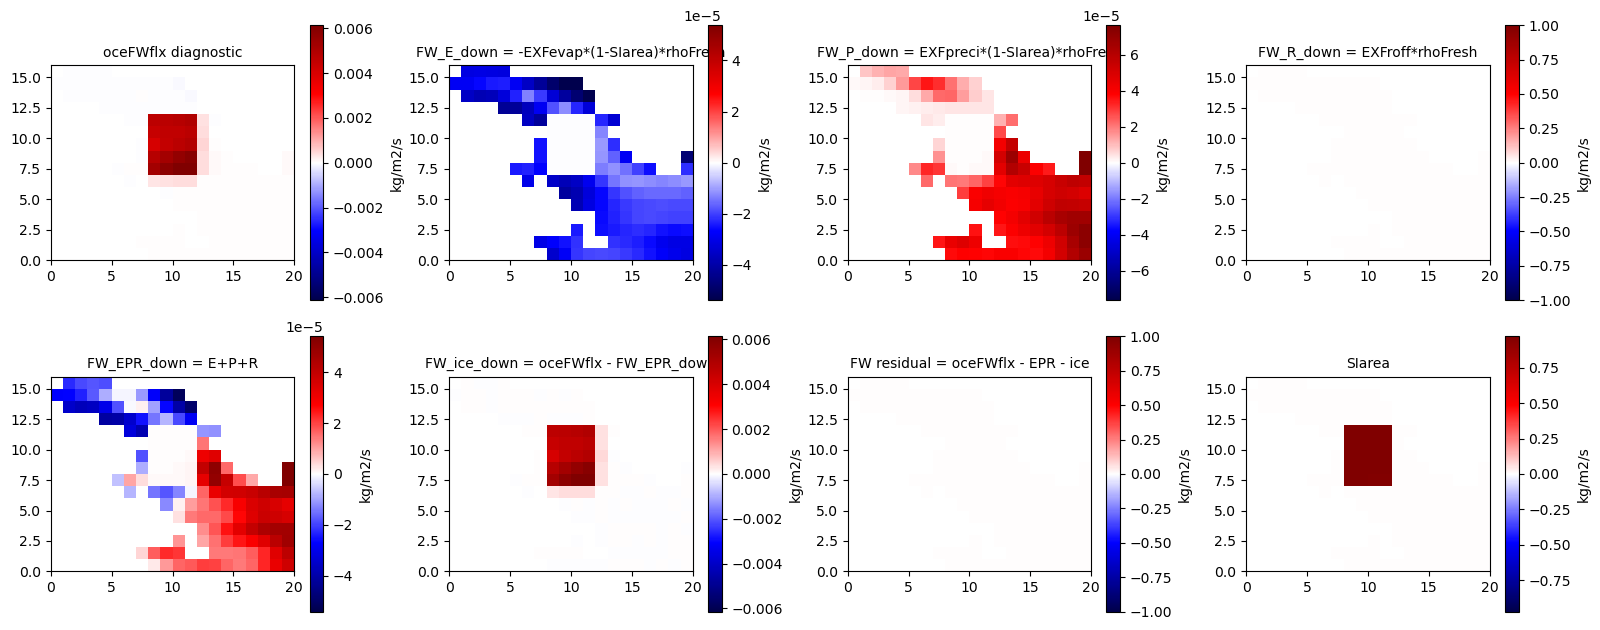

In [41]:
# Positive-down freshwater pieces, matching the sign of oceFWflx.
# seaice_growth.F uses (EVAP-PRECIP)*(1-AREApreTH) - RUNOFF in EmPmR,
# and oceFWflx = -EmPmR.  This makes precipitation/runoff positive-down
# and evaporation negative-down.
rhoFresh = 1000.0
open_water = 1.0 - SIarea

FW_E_down = -EXFevap * open_water * rhoFresh
FW_P_down =  EXFpreci * open_water * rhoFresh
FW_R_down =  EXFroff * rhoFresh
FW_EPR_down = FW_E_down + FW_P_down + FW_R_down
FW_ice_down = oceFWflx - FW_EPR_down

fw_split_terms = {
    "oceFWflx diagnostic": oceFWflx * mask,
    "FW_E_down = -EXFevap*(1-SIarea)*rhoFresh": FW_E_down * mask,
    "FW_P_down = EXFpreci*(1-SIarea)*rhoFresh": FW_P_down * mask,
    "FW_R_down = EXFroff*rhoFresh": FW_R_down * mask,
    "FW_EPR_down = E+P+R": FW_EPR_down * mask,
    "FW_ice_down = oceFWflx - FW_EPR_down": FW_ice_down * mask,
    "FW residual = oceFWflx - EPR - ice": (oceFWflx - FW_EPR_down - FW_ice_down) * mask,
    "SIarea": SIarea * mask,
}

plot_option_grid(fw_split_terms, units="kg/m2/s", ncols=4, robust_pct=99.0)
print_integrals(fw_split_terms, area=area, label="FW split")


SFLUX-surForcS split: SFLUX - surForcS diagnostic: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
SFLUX-surForcS split: oceFWflx*SALT_surface: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
SFLUX-surForcS split: E contribution = -EXFevap*(1-SIarea)*rhoFresh*SALT: min=-1.894331e-03, mean=-7.448442e-04, max=-3.971682e-07, area_sum=-2.596163e+09
SFLUX-surForcS split: P contribution = EXFpreci*(1-SIarea)*rhoFresh*SALT: min= 2.844285e-06, mean= 1.021737e-03, max= 3.554173e-03, area_sum= 4.172114e+09
SFLUX-surForcS split: R contribution = EXFroff*rhoFresh*SALT: min= 0.000000e+00, mean= 0.000000e+00, max= 0.000000e+00, area_sum= 0.000000e+00
SFLUX-surForcS split: EPR contribution = FW_EPR_down*SALT: min=-1.674536e-03, mean= 2.768927e-04, max= 1.995078e-03, area_sum= 1.575950e+09
SFLUX-surForcS split: ice contribution = FW_ice_down*SALT: min=-7.856328e-11, mean= 2.284311e-02, max= 2.277293e-01, area_sum= 7.254720e+10
SFLUX-sur

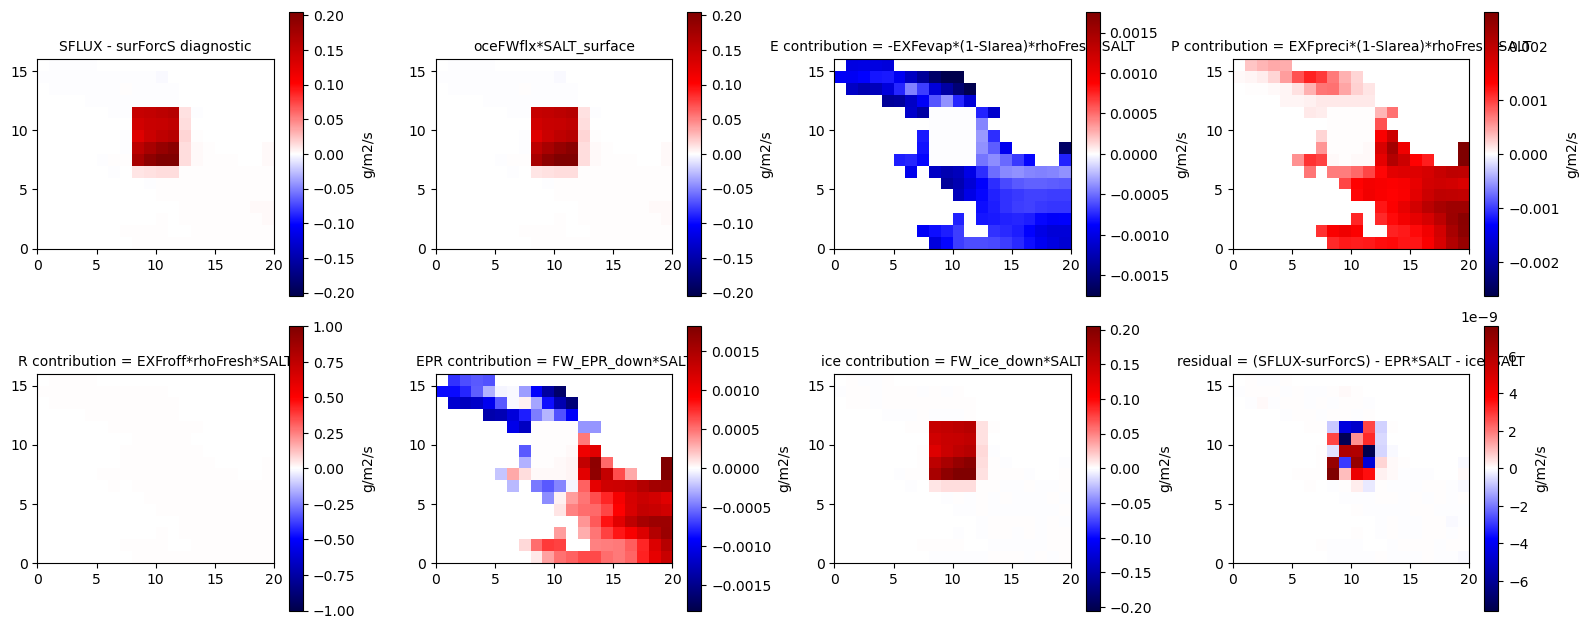

In [42]:
# Same split after multiplying by surface salinity: this is the term that appears in SFLUX - surForcS.
S_adv_total = oceFWflx * salt_surface
S_adv_E = FW_E_down * salt_surface
S_adv_P = FW_P_down * salt_surface
S_adv_R = FW_R_down * salt_surface
S_adv_EPR = FW_EPR_down * salt_surface
S_adv_ice = FW_ice_down * salt_surface

salt_split_terms = {
    "SFLUX - surForcS diagnostic": (SFLUX - surForcS) * mask,
    "oceFWflx*SALT_surface": S_adv_total * mask,
    "E contribution = -EXFevap*(1-SIarea)*rhoFresh*SALT": S_adv_E * mask,
    "P contribution = EXFpreci*(1-SIarea)*rhoFresh*SALT": S_adv_P * mask,
    "R contribution = EXFroff*rhoFresh*SALT": S_adv_R * mask,
    "EPR contribution = FW_EPR_down*SALT": S_adv_EPR * mask,
    "ice contribution = FW_ice_down*SALT": S_adv_ice * mask,
    "residual = (SFLUX-surForcS) - EPR*SALT - ice*SALT": ((SFLUX - surForcS) - S_adv_EPR - S_adv_ice) * mask,
}

plot_option_grid(salt_split_terms, units="g/m2/s", ncols=4, robust_pct=99.0)
print_integrals(salt_split_terms, area=area, label="SFLUX-surForcS split")


compact SFLUX-surForcS split: diagnostic: SFLUX - surForcS: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
compact SFLUX-surForcS split: E/P/R salt contribution: min=-1.674536e-03, mean= 2.768927e-04, max= 1.995078e-03, area_sum= 1.575950e+09
compact SFLUX-surForcS split: ice freshwater salt contribution: min=-7.856328e-11, mean= 2.284311e-02, max= 2.277293e-01, area_sum= 7.254720e+10
compact SFLUX-surForcS split: E/P/R + ice: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
compact SFLUX-surForcS split: closure residual: min=-7.814929e-09, mean= 1.310728e-10, max= 8.220781e-09, area_sum= 4.966928e+02


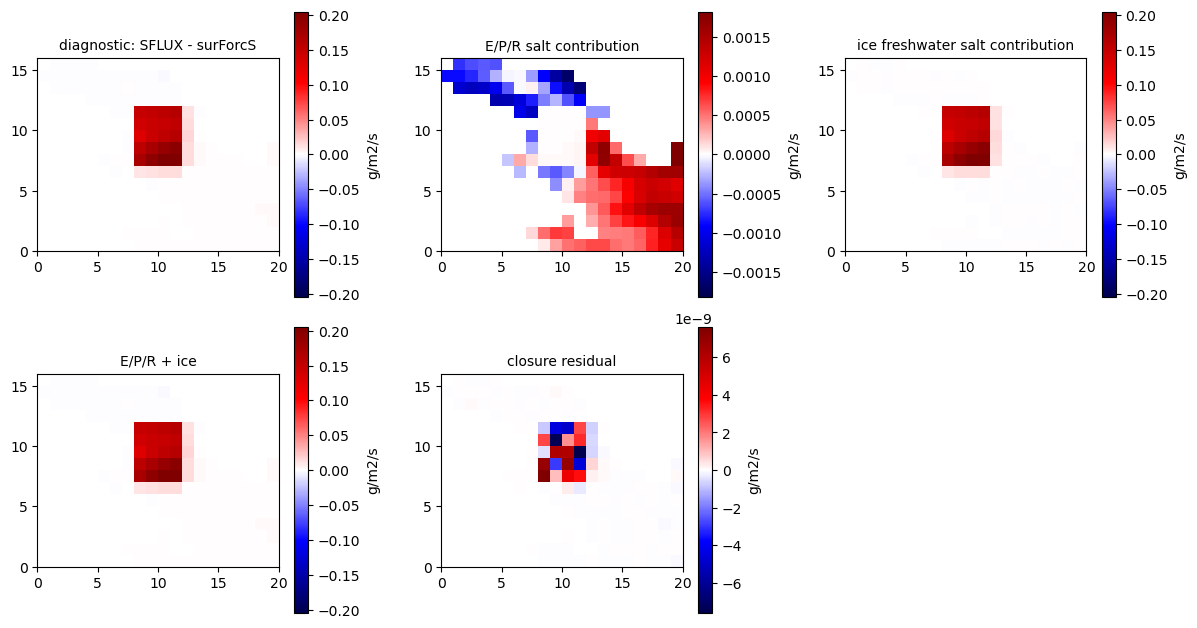

In [43]:
# Compact view: total salt-advection term, two grouped contributions, and closure residual.
compact_split_terms = {
    "diagnostic: SFLUX - surForcS": (SFLUX - surForcS) * mask,
    "E/P/R salt contribution": S_adv_EPR * mask,
    "ice freshwater salt contribution": S_adv_ice * mask,
    "E/P/R + ice": (S_adv_EPR + S_adv_ice) * mask,
    "closure residual": ((SFLUX - surForcS) - (S_adv_EPR + S_adv_ice)) * mask,
}

plot_option_grid(compact_split_terms, units="g/m2/s", ncols=3, robust_pct=99.0)
print_integrals(compact_split_terms, area=area, label="compact SFLUX-surForcS split")


### Salt-flux-only breakdown: no open-ocean E/P/R source

This section keeps the salt-flux diagnostic separate from the freshwater diagnostic.

From `diags_oceanic_surf_flux.F`:

`oceSflux = -saltFlux`

From `seaice_growth.F`, `saltFlux` is generated by sea-ice salt exchange. Open-ocean `EVAP`, `PRECIP`, and `RUNOFF` enter `oceFWflx`, not `oceSflux`. They should not be plotted as an open-ocean contribution to `oceSflux`.


saltFlux/oceSflux only: oceSflux diagnostic = -saltFlux: min= 0.000000e+00, mean= 2.464879e-03, max= 2.376252e-02, area_sum= 7.815183e+09
saltFlux/oceSflux only: loaded estimate: -(OCN+ATC+ATO+FLO)*Sice*rhoIce: min=-0.000000e+00, mean= 2.483828e-03, max= 2.394531e-02, area_sum= 7.875258e+09
saltFlux/oceSflux only: residual: oceSflux - loaded estimate: min=-1.827886e-04, mean=-1.894946e-05, max= 1.659249e-06, area_sum=-6.007421e+07
saltFlux/oceSflux only: OCN contribution: -SIdHbOCN*Sice*rhoIce: min=-0.000000e+00, mean= 2.840051e-03, max= 2.730538e-02, area_sum= 8.998826e+09
saltFlux/oceSflux only: ATC contribution: -SIdHbATC*Sice*rhoIce: min=-1.978057e-04, mean=-1.688155e-05, max=-0.000000e+00, area_sum=-5.134399e+07
saltFlux/oceSflux only: ATO contribution: -SIdHbATO*Sice*rhoIce: min=-2.318140e-04, mean=-1.946893e-05, max=-0.000000e+00, area_sum=-6.017382e+07
saltFlux/oceSflux only: FLO contribution: -SIdHbFLO*Sice*rhoIce: min=-3.234882e-03, mean=-3.198729e-04, max=-0.000000e+00, area

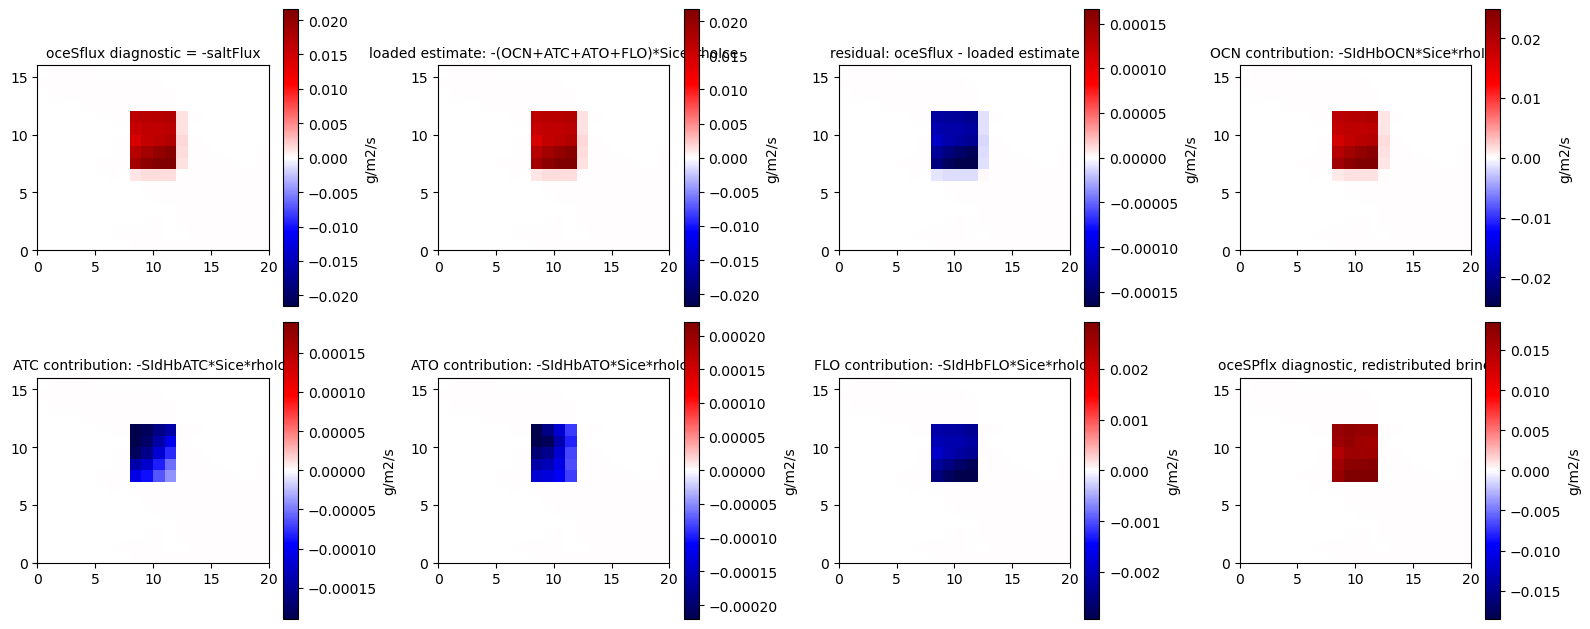

In [44]:
# Salt-flux-only pieces.  These are the terms that can contribute to oceSflux.
# E/P/R are deliberately excluded here: they are freshwater fluxes, not saltFlux sources.
rhoIce = 917.0
SEAICE_salt0 = 4.0
sice = np.maximum(0.0, np.minimum(SEAICE_salt0, salt_surface))

saltFlux_OCN = SIdHbOCN * sice * rhoIce
saltFlux_ATC = SIdHbATC * sice * rhoIce
saltFlux_ATO = SIdHbATO * sice * rhoIce
saltFlux_FLO = SIdHbFLO * sice * rhoIce
saltFlux_loaded = saltFlux_OCN + saltFlux_ATC + saltFlux_ATO + saltFlux_FLO

oceSflux_loaded = -saltFlux_loaded
oceSflux_missing = oceSflux - oceSflux_loaded

salt_only_terms = {
    "oceSflux diagnostic = -saltFlux": oceSflux * mask,
    "loaded estimate: -(OCN+ATC+ATO+FLO)*Sice*rhoIce": oceSflux_loaded * mask,
    "residual: oceSflux - loaded estimate": oceSflux_missing * mask,
    "OCN contribution: -SIdHbOCN*Sice*rhoIce": (-saltFlux_OCN) * mask,
    "ATC contribution: -SIdHbATC*Sice*rhoIce": (-saltFlux_ATC) * mask,
    "ATO contribution: -SIdHbATO*Sice*rhoIce": (-saltFlux_ATO) * mask,
    "FLO contribution: -SIdHbFLO*Sice*rhoIce": (-saltFlux_FLO) * mask,
    "oceSPflx diagnostic, redistributed brine": oceSPflx * mask,
}

plot_option_grid(salt_only_terms, units="g/m2/s", ncols=4, robust_pct=99.0)
print_integrals(salt_only_terms, area=area, label="saltFlux/oceSflux only")


SFLUX salt-only closure: SFLUX diagnostic: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX salt-only closure: oceSflux - oceSPflx: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
SFLUX salt-only closure: loaded estimate - oceSPflx: min=-7.198091e-04, mean= 2.183963e-04, max= 4.893147e-03, area_sum= 7.606050e+08
SFLUX salt-only closure: exact residual: SFLUX - (oceSflux-oceSPflx): min=-1.734723e-17, mean= 1.731742e-18, max= 4.163336e-17, area_sum= 5.510773e-06
SFLUX salt-only closure: loaded residual: SFLUX - (loaded estimate-oceSPflx): min=-1.827886e-04, mean=-1.894946e-05, max= 1.659249e-06, area_sum=-6.007421e+07


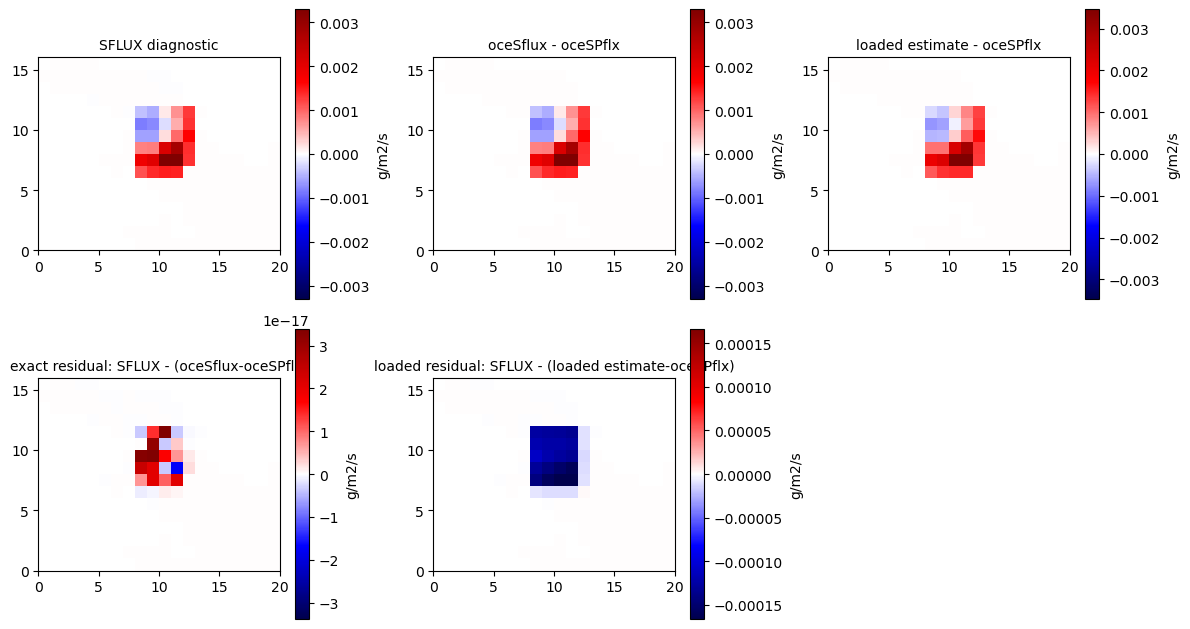

In [45]:
# SFLUX closure using only saltFlux and salt-plume redistribution.
# This is the correct salt-source interpretation:
#   SFLUX = oceSflux - oceSPflx
# E/P/R do not appear in this equation as separate open-ocean salt sources.
sflux_salt_only_terms = {
    "SFLUX diagnostic": SFLUX * mask,
    "oceSflux - oceSPflx": (oceSflux - oceSPflx) * mask,
    "loaded estimate - oceSPflx": (oceSflux_loaded - oceSPflx) * mask,
    "exact residual: SFLUX - (oceSflux-oceSPflx)": (SFLUX - (oceSflux - oceSPflx)) * mask,
    "loaded residual: SFLUX - (loaded estimate-oceSPflx)": (SFLUX - (oceSflux_loaded - oceSPflx)) * mask,
}

plot_option_grid(sflux_salt_only_terms, units="g/m2/s", ncols=3, robust_pct=99.0)
print_integrals(sflux_salt_only_terms, area=area, label="SFLUX salt-only closure")


freshwater context only: SFLUX - surForcS = oceFWflx*SALT: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
freshwater context only: oceFWflx*SALT: min=-1.674536e-03, mean= 2.312000e-02, max= 2.277635e-01, area_sum= 7.412315e+10
freshwater context only: FW context residual: min=-7.814929e-09, mean= 1.310728e-10, max= 8.220781e-09, area_sum= 4.966928e+02
freshwater context only: oceFWflx diagnostic: min=-5.182153e-05, mean= 7.065689e-04, max= 6.747317e-03, area_sum= 2.261362e+09
freshwater context only: SIarea: min= 0.000000e+00, mean= 1.290920e-01, max= 9.713436e-01, area_sum= 4.041162e+11


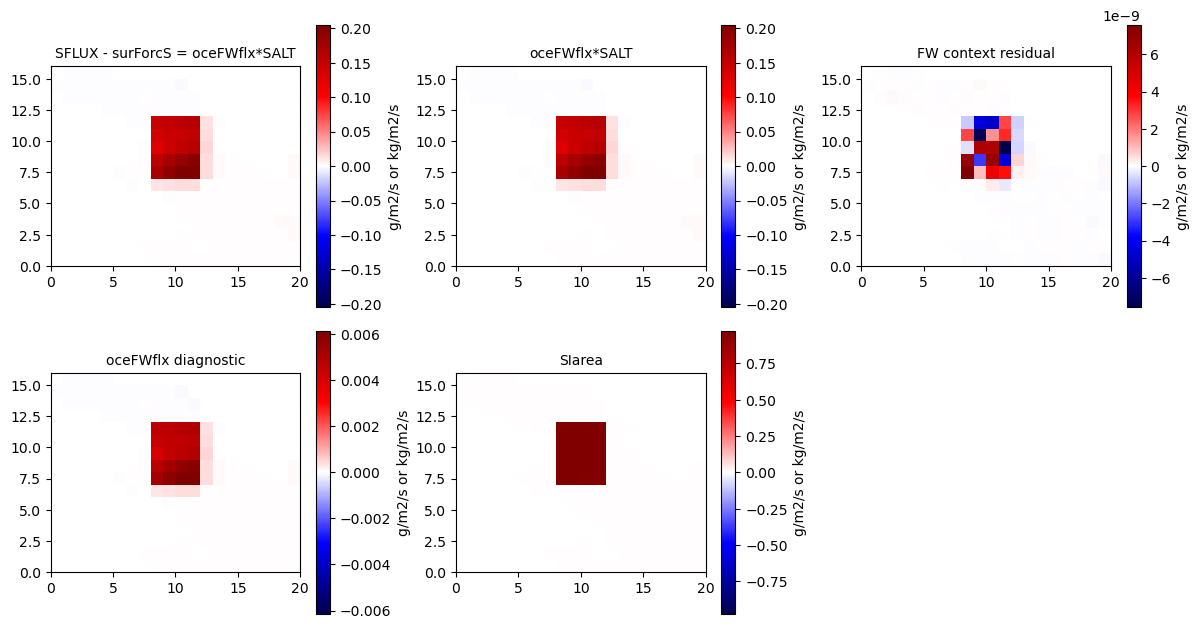

In [46]:
# Freshwater diagnostics are still useful, but only as context for SFLUX-surForcS.
# They should be interpreted as volume/freshwater advection, not saltFlux source.
freshwater_context_terms = {
    "SFLUX - surForcS = oceFWflx*SALT": (SFLUX - surForcS) * mask,
    "oceFWflx*SALT": (oceFWflx * salt_surface) * mask,
    "FW context residual": ((SFLUX - surForcS) - oceFWflx * salt_surface) * mask,
    "oceFWflx diagnostic": oceFWflx * mask,
    "SIarea": SIarea * mask,
}

plot_option_grid(freshwater_context_terms, units="g/m2/s or kg/m2/s", ncols=3, robust_pct=99.0)
print_integrals(freshwater_context_terms, area=area, label="freshwater context only")


### Final SFLUX synthesis plot

This section puts the three checks together:

1. Salt-flux closure: `SFLUX = oceSflux - oceSPflx`.
2. Freshwater-context closure: `SFLUX = surForcS + oceFWflx*SALT_surface`, so `(SFLUX-surForcS) - oceFWflx*SALT_surface` should be near zero.
3. Partial ice-term reconstruction: `oceSflux ~= -(SIdHbOCN+SIdHbATC+SIdHbATO+SIdHbFLO)*Sice*rhoIce`, with the remaining residual showing unloaded ice terms.


final synthesis: SFLUX diagnostic: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
final synthesis: salt closure: oceSflux - oceSPflx: min=-8.401062e-04, mean= 1.994468e-04, max= 4.710359e-03, area_sum= 7.005308e+08
final synthesis: salt closure residual: min=-1.734723e-17, mean= 1.731742e-18, max= 4.163336e-17, area_sum= 5.510773e-06
final synthesis: FW-context closure: surForcS + oceFWflx*SALT: min=-8.401089e-04, mean= 1.994467e-04, max= 4.710355e-03, area_sum= 7.005303e+08
final synthesis: FW-context residual: (SFLUX-surForcS)-oceFWflx*SALT: min=-7.814929e-09, mean= 1.310728e-10, max= 8.220781e-09, area_sum= 4.966928e+02
final synthesis: oceSflux diagnostic: min= 0.000000e+00, mean= 2.464879e-03, max= 2.376252e-02, area_sum= 7.815183e+09
final synthesis: oceSflux from loaded ice terms: min=-0.000000e+00, mean= 2.483828e-03, max= 2.394531e-02, area_sum= 7.875258e+09
final synthesis: oceSflux residual from unloaded ice terms: min=-1.827886e-04, mean=-1

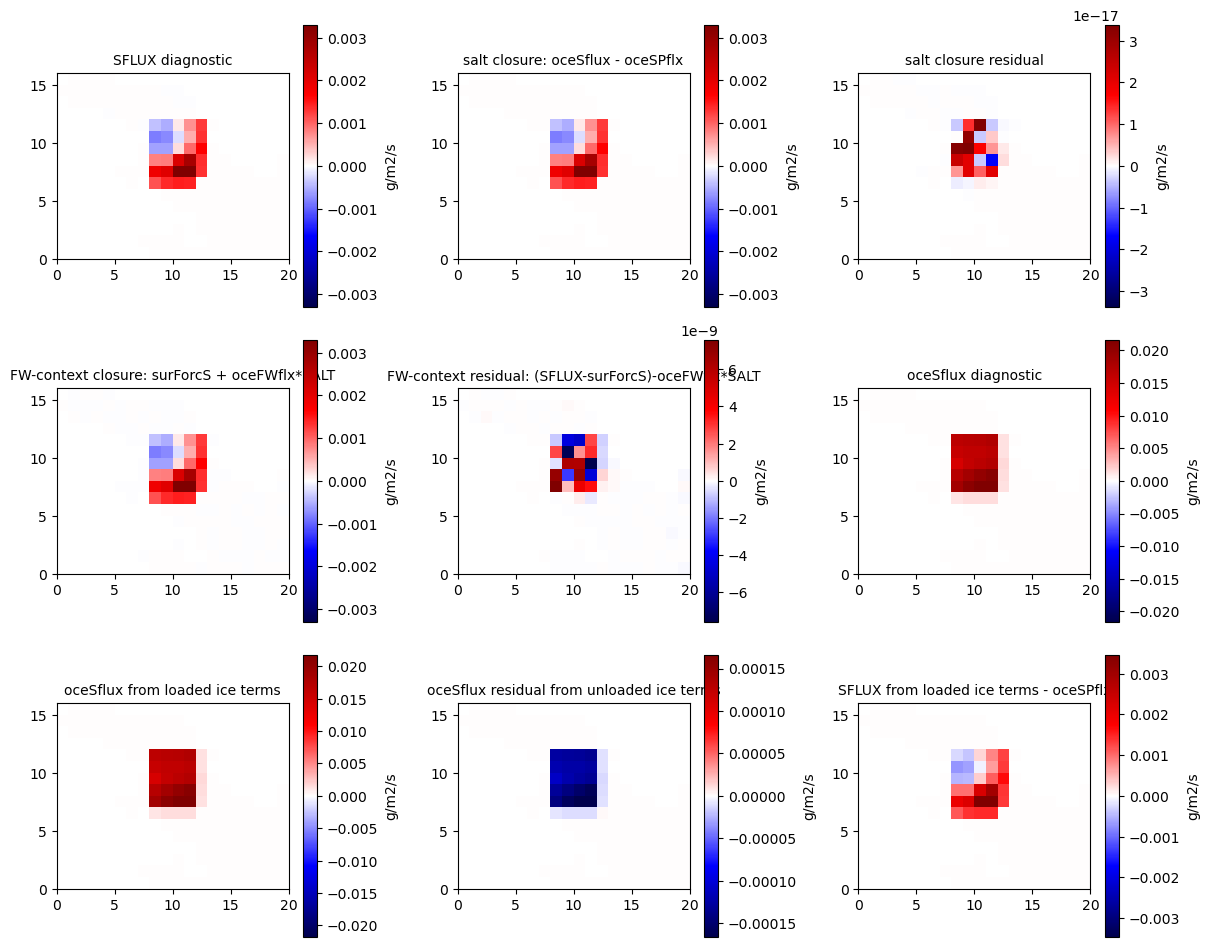

In [47]:
# Final synthesis of the two exact SFLUX closures and the partial oceSflux ice-term reconstruction.
rhoIce = 917.0
SEAICE_salt0 = 4.0
sice = np.maximum(0.0, np.minimum(SEAICE_salt0, salt_surface))

# Exact diagnostic closures.
sflux_from_oce_salt = oceSflux - oceSPflx
sflux_from_surfforc_fw = surForcS + oceFWflx * salt_surface
fw_context_residual = (SFLUX - surForcS) - oceFWflx * salt_surface

# Loaded sea-ice saltFlux reconstruction.  This is intentionally partial because
# d_HEFFbyNEG, exact d_HEFFbySublim, and saltFluxAdjust are not all in this output set.
saltFlux_loaded = (
    SIdHbOCN * sice * rhoIce
    + SIdHbATC * sice * rhoIce
    + SIdHbATO * sice * rhoIce
    + SIdHbFLO * sice * rhoIce
)
oceSflux_from_loaded_ice = -saltFlux_loaded
sflux_from_loaded_ice = oceSflux_from_loaded_ice - oceSPflx

synthesis_terms = {
    "SFLUX diagnostic": SFLUX * mask,
    "salt closure: oceSflux - oceSPflx": sflux_from_oce_salt * mask,
    "salt closure residual": (SFLUX - sflux_from_oce_salt) * mask,
    "FW-context closure: surForcS + oceFWflx*SALT": sflux_from_surfforc_fw * mask,
    "FW-context residual: (SFLUX-surForcS)-oceFWflx*SALT": fw_context_residual * mask,
    "oceSflux diagnostic": oceSflux * mask,
    "oceSflux from loaded ice terms": oceSflux_from_loaded_ice * mask,
    "oceSflux residual from unloaded ice terms": (oceSflux - oceSflux_from_loaded_ice) * mask,
    "SFLUX from loaded ice terms - oceSPflx": sflux_from_loaded_ice * mask,
}

plot_option_grid(synthesis_terms, units="g/m2/s", ncols=3, robust_pct=99.0)
print_integrals(synthesis_terms, area=area, label="final synthesis")


In [48]:
# Compact numerical summary for the synthesis plot.
def area_mean(field):
    return np.nansum(field * area) / np.nansum(area)

def area_sum(field):
    return np.nansum(field * area)

SIarea_mask = SIarea
SIarea_mask[SIarea_mask > 0 ]=1

summary_terms = {
    "SFLUX": SFLUX * mask,
    "oceSflux - oceSPflx": sflux_from_oce_salt * mask,
    "SFLUX - (oceSflux-oceSPflx)": (SFLUX - sflux_from_oce_salt) * mask,
    "surForcS + oceFWflx*SALT": sflux_from_surfforc_fw * mask,
    "FW-context residual": fw_context_residual * mask,
    "oceSflux": oceSflux * mask,
    "oceSflux from loaded ice terms": oceSflux_from_loaded_ice * mask,
    "unloaded ice-term residual": (oceSflux - oceSflux_from_loaded_ice) * mask,
}

print("Final SFLUX synthesis summary")
print("name                                      area_mean       area_sum        min            max")
for name, fld in summary_terms.items():
    values = np.asarray(fld, dtype=float)
    print(
        f"{name:40s} "
        f"{area_mean(values): .6e} "
        f"{area_sum(values): .6e} "
        f"{np.nanmin(values): .6e} "
        f"{np.nanmax(values): .6e}"
    )

print("\nInterpretation:")
print("1. SFLUX and oceSflux-oceSPflx should match to roundoff.")
print("2. FW-context residual should be near zero; this verifies the diagnostic freshwater cancellation, not an open-ocean salt source.")
print("3. oceSflux minus loaded ice terms is the part of saltFlux from unloaded ice terms such as d_HEFFbyNEG, exact d_HEFFbySublim, and any adjustment terms.")


Final SFLUX synthesis summary
name                                      area_mean       area_sum        min            max
SFLUX                                     1.966387e-04  7.005308e+08 -8.401062e-04  4.710359e-03
oceSflux - oceSPflx                       1.966387e-04  7.005308e+08 -8.401062e-04  4.710359e-03
SFLUX - (oceSflux-oceSPflx)               1.546872e-18  5.510773e-06 -1.734723e-17  4.163336e-17
surForcS + oceFWflx*SALT                  1.966385e-04  7.005303e+08 -8.401089e-04  4.710355e-03
FW-context residual                       1.394215e-10  4.966928e+02 -7.814929e-09  8.220781e-09
oceSflux                                  2.193718e-03  7.815183e+09  0.000000e+00  2.376252e-02
oceSflux from loaded ice terms            2.210581e-03  7.875258e+09 -0.000000e+00  2.394531e-02
unloaded ice-term residual               -1.686280e-05 -6.007421e+07 -1.827886e-04  1.659249e-06

Interpretation:
1. SFLUX and oceSflux-oceSPflx should match to roundoff.
2. FW-context residual shou

In [49]:
# # we need to output:
# SIdHbNEG  = d_HEFFbyNEG / dt
# SIdHbSUB  = d_HEFFbySublim / dt
# SIdHbRLX  = d_HEFFbyRLX / dt, if compiled

### oceSflux residual from snapshot dSIheff

This uses the finite-difference `dSIheff = (SIheff[t2]-SIheff[t1])/dt` directly, instead of the thermodynamic `SIdHb*` diagnostics. It is not expected to be exact because snapshot `dSIheff` can include dynamics/advection and other updates that are not the same as the thermodynamic saltFlux source terms.


oceSflux from snapshot dSIheff summary
name                                      area_mean       area_sum        min            max
oceSflux diagnostic                       2.193718e-03  7.815183e+09  0.000000e+00  2.376252e-02
oceSflux from snapshot dSIheff            2.210593e-03  7.875300e+09 -0.000000e+00  2.266206e-02
residual: oceSflux - dSIheff estimate    -1.687476e-05 -6.011679e+07 -3.633926e-03  1.658087e-03
SFLUX diagnostic                          1.966387e-04  7.005308e+08 -8.401062e-04  4.710359e-03
SFLUX from dSIheff estimate - oceSPflx    2.135134e-04  7.606475e+08 -1.069012e-44  3.609892e-03
residual: SFLUX - (dSIheff estimate - oceSPflx) -1.687476e-05 -6.011679e+07 -3.633926e-03  1.658087e-03
dSIheff snapshot tendency                -6.026699e-07 -2.147028e+06 -6.178314e-06  0.000000e+00
Sice=min(SEAICE_salt0,SSS)                4.000000e+00  1.425011e+13  4.000000e+00  4.000000e+00

Interpretation:
This checks whether total snapshot SIheff tendency has the same scal

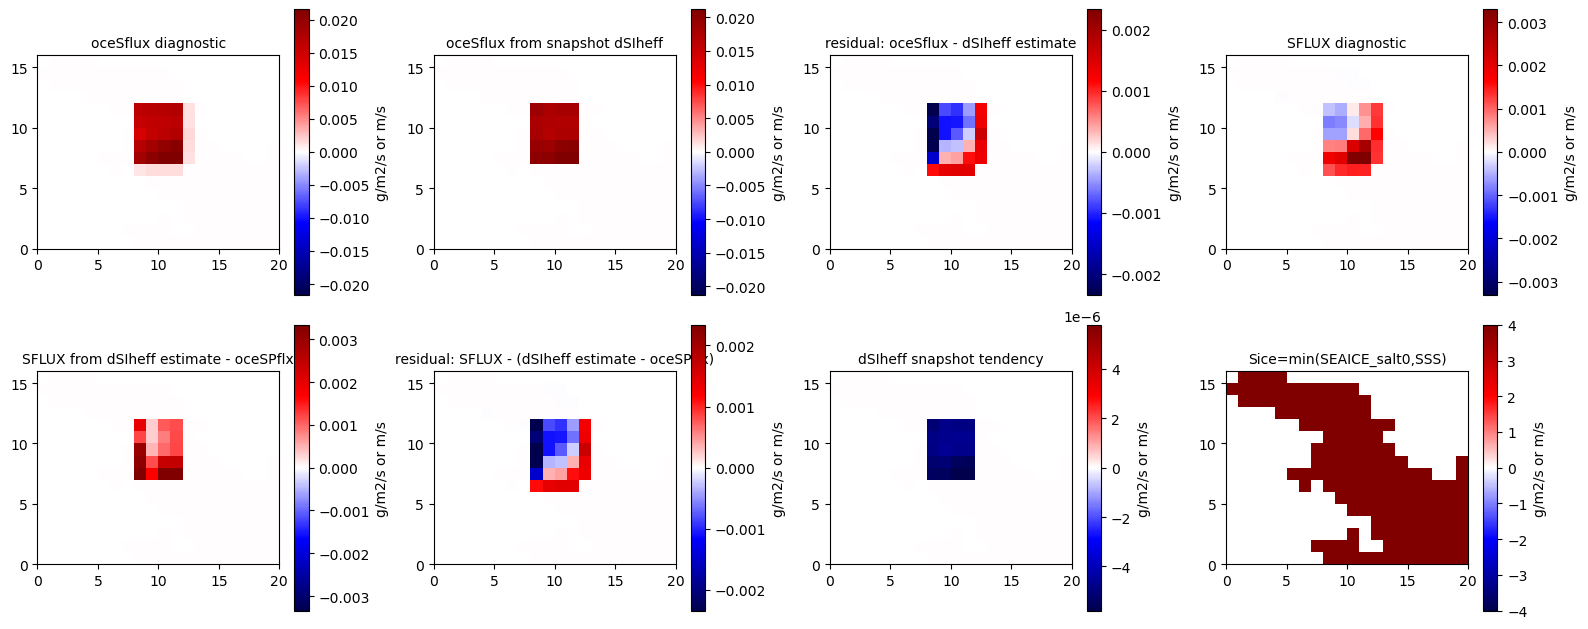

In [50]:
# Reconstruct oceSflux from the total snapshot tendency dSIheff.
# For the constant sea-ice salinity branch, a simple estimate is:
#   saltFlux_from_dSIheff = dSIheff * min(SEAICE_salt0, SSS) * rhoIce
#   oceSflux_from_dSIheff = -saltFlux_from_dSIheff
rhoIce = 917.0
SEAICE_salt0 = 4.0
sice = np.maximum(0.0, np.minimum(SEAICE_salt0, salt_surface))

saltFlux_from_dSIheff = dSIheff * sice * rhoIce
oceSflux_from_dSIheff = -saltFlux_from_dSIheff
sflux_from_dSIheff = oceSflux_from_dSIheff - oceSPflx

dSIheff_terms = {
    "oceSflux diagnostic": oceSflux * mask,
    "oceSflux from snapshot dSIheff": oceSflux_from_dSIheff * mask,
    "residual: oceSflux - dSIheff estimate": (oceSflux - oceSflux_from_dSIheff) * mask,
    "SFLUX diagnostic": SFLUX * mask,
    "SFLUX from dSIheff estimate - oceSPflx": sflux_from_dSIheff * mask,
    "residual: SFLUX - (dSIheff estimate - oceSPflx)": (SFLUX - sflux_from_dSIheff) * mask,
    "dSIheff snapshot tendency": dSIheff * mask,
    "Sice=min(SEAICE_salt0,SSS)": sice * mask,
}

plot_option_grid(dSIheff_terms, units="g/m2/s or m/s", ncols=4, robust_pct=99.0)

print("oceSflux from snapshot dSIheff summary")
print("name                                      area_mean       area_sum        min            max")
for name, fld in dSIheff_terms.items():
    values = np.asarray(fld, dtype=float)
    print(
        f"{name:40s} "
        f"{area_mean(values): .6e} "
        f"{area_sum(values): .6e} "
        f"{np.nanmin(values): .6e} "
        f"{np.nanmax(values): .6e}"
    )

print("\nInterpretation:")
print("This checks whether total snapshot SIheff tendency has the same scale/pattern as oceSflux.")
print("A residual is expected because seaice_growth.F uses thermodynamic d_HEFF components for saltFlux, not necessarily total dSIheff.")


### TFLUX synthesis: what can you learn?

This block treats `TFLUX` as the surface heat-flux analogue of the salt-flux checks above.  The useful questions are:

1. Does the diagnostic close as `surForcT + oceFreez + oceQsw + oceFWflx*THETA_surface*Cp`?
2. How much of the signal is atmospheric/sea-ice heat exchange, shortwave, freezing/melting, or real-freshwater heat advection?
3. Are the largest terms under sea ice, in open water, or concentrated where `SIarea` changes?

Interpret signs using the model diagnostic convention in this notebook.  In the summary table, positive and negative means show the net heating/cooling sense of each term with that convention, while the residual rows are the main sanity checks.


In [ ]:
# Final TFLUX synthesis: closure, components, and ice/open-water context.
# This mirrors the SFLUX workflow but keeps the heat terms in W/m2.
import importlib
import flux_breakdown_plot_options as fbpo
importlib.reload(fbpo)
from flux_breakdown_plot_options import *

mask = mygrid["hFacC"][0]
area = mygrid["RAC"] * mask
theta_surface = THETA[0]
Cp = 3994.0

data = combine_diagnostic_dicts(budg1, budg2, extra_seaice, extra_exf, state2d)

# Main reconstruction from diags_oceanic_surf_flux.F logic used by tflux_options().
FW_heat = oceFWflx * theta_surface * Cp
TFLUX_recon = surForcT + oceFreez + oceQsw + FW_heat
TFLUX_resid = TFLUX - TFLUX_recon

# Direct closure terms and physically interpretable components.
TFLUX_terms = {
    "TFLUX diagnostic": TFLUX * mask,
    "surForcT": surForcT * mask,
    "oceFreez": oceFreez * mask,
    "oceQsw": oceQsw * mask,
    "FW heat: oceFWflx*THETA*Cp": FW_heat * mask,
    "reconstruction": TFLUX_recon * mask,
    "residual: TFLUX - reconstruction": TFLUX_resid * mask,
}

plot_option_grid(TFLUX_terms, units="W/m2", ncols=4, robust_pct=99.0)

# Compact numerical summary.  The area integral is W, since W/m2 is multiplied by cell area.
def _area_mean(field, weights):
    return np.nansum(field * weights) / np.nansum(weights)

def _area_sum(field, weights):
    return np.nansum(field * weights)

def _print_tflux_summary(label, selector):
    weights = np.where(selector, area, np.nan)
    print(f"\n{label}")
    print("name                                      area_mean_Wm2       area_sum_W")
    for name, field in TFLUX_terms.items():
        raw = np.asarray(field, dtype=float)
        # TFLUX_terms are already masked; divide by mask only where finite so means are not double-masked.
        values = np.where(np.isfinite(mask) & (mask != 0), raw / mask, np.nan)
        print(f"{name:40s} {_area_mean(values, weights): .6e} {_area_sum(values, weights): .6e}")

water = np.isfinite(mask) & (mask > 0)
ice_covered = water & np.isfinite(SIarea) & (SIarea > 0.15)
open_water = water & np.isfinite(SIarea) & (SIarea <= 0.15)

_print_tflux_summary("All wet surface cells", water)
_print_tflux_summary("Ice-covered cells, SIarea > 0.15", ice_covered)
_print_tflux_summary("Open-water cells, SIarea <= 0.15", open_water)

# Fractional contribution to the reconstructed area-integrated TFLUX.
components = {
    "surForcT": surForcT,
    "oceFreez": oceFreez,
    "oceQsw": oceQsw,
    "FW_heat": FW_heat,
}
recon_sum = _area_sum(TFLUX_recon, area)
print("\nArea-integrated contribution relative to reconstructed TFLUX")
print("name                                      area_sum_W       fraction")
for name, field in components.items():
    asum = _area_sum(field, area)
    frac = asum / recon_sum if np.isfinite(recon_sum) and recon_sum != 0 else np.nan
    print(f"{name:40s} {asum: .6e} {frac: .6e}")

print("\nInterpretation guide:")
print("1. If the residual is near numerical precision, TFLUX is explained by surForcT, oceFreez, oceQsw, and freshwater heat advection.")
print("2. surForcT is the bulk non-shortwave surface forcing path; oceQsw isolates penetrative shortwave handling.")
print("3. oceFreez highlights heat exchanged through freezing/melting; compare it with SIarea and dSIheff patterns.")
